# Day 3: Univariate & Bivariate EDA

## Objective

The objective of this stage is to analyze the distribution of variables and explore relationships between features in the hotel booking dataset. This analysis helps identify customer behavior patterns, booking trends, pricing characteristics, cancellation factors, and business insights.

## Tasks Performed

1. Univariate Analysis
   - Histogram
   - KDE Plot
   - Boxplot

2. Categorical Univariate Analysis
   - Frequency Tables
   - Bar Charts

3. Numeric–Numeric Analysis
   - Scatterplots
   - Correlation Heatmap

4. Numeric–Categorical Analysis
   - Boxplots
   - Grouped Barplots

5. Segment Analysis

6. Export Important Figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/interim/cleaned_day2.csv")

df.shape

(87370, 31)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87370 entries, 0 to 87369
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87370 non-null  object 
 1   is_canceled                     87370 non-null  int64  
 2   lead_time                       87370 non-null  int64  
 3   arrival_date_year               87370 non-null  int64  
 4   arrival_date_month              87370 non-null  object 
 5   arrival_date_week_number        87370 non-null  int64  
 6   arrival_date_day_of_month       87370 non-null  int64  
 7   stays_in_weekend_nights         87370 non-null  int64  
 8   stays_in_week_nights            87370 non-null  int64  
 9   adults                          87370 non-null  int64  
 10  children                        87370 non-null  float64
 11  babies                          87370 non-null  int64  
 12  meal                            

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(87370, 31)

## Dataset Verification

### Use Case

Before performing exploratory data analysis, the cleaned dataset is verified to ensure that all preprocessing steps from Day 2 were successfully completed.

### Key Findings

- Dataset contains 87,370 records.
- Dataset contains 31 features.
- No missing values remain in the dataset.
- No duplicate records remain in the dataset.

### Interpretation

The dataset is complete, consistent, and ready for exploratory data analysis.

### Business Insight

Accurate customer behavior analysis and booking trend analysis require clean and reliable data. Verifying the dataset ensures confidence in all future findings.

### Conclusion

The dataset passed all quality checks and is ready for univariate and bivariate analysis.



# Univariate Analysis

Univariate Analysis is the process of examining and summarizing a single variable at a time. The primary objective is to understand the distribution, central tendency, spread, and overall characteristics of individual features within the dataset.

In this analysis, numerical variables are explored using statistical summaries, histograms, KDE plots, and boxplots to identify patterns, skewness, and potential outliers. Categorical variables are analyzed using frequency tables and count plots to understand the distribution of categories.

This step provides a foundational understanding of the dataset and helps identify data quality issues, unusual observations, and important business insights before moving on to more advanced analyses.

# Lead Time Analysis

## Why this Variable?

Lead Time represents the number of days between the booking date and the customer's arrival date. It is one of the most important customer behavior variables in the hotel booking dataset because it reflects how far in advance customers plan their reservations.

## Objective

To understand customer booking behavior, identify booking patterns, detect unusual booking trends, and evaluate how early customers make reservations before their stay.

## Business Importance

Lead Time directly influences:

* Demand forecasting
* Occupancy planning
* Revenue management
* Dynamic pricing strategies
* Marketing campaign planning

Understanding Lead Time helps hotels predict future demand and optimize pricing decisions.


In [11]:
df['lead_time'].describe()

count    87370.000000
mean        79.911686
std         86.056471
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64

## Lead Time - Descriptive Statistics


The `describe()` function is used to generate summary statistics for a numerical variable. It helps understand the central tendency, spread, and overall distribution of the data before visualization.

### Findings

- Total bookings analyzed: 87,370
- Average lead time: 79.91 days
- Median lead time: 49 days
- Standard deviation: 86.06 days
- Minimum lead time: 0 days
- Maximum lead time: 737 days
- 25% of customers booked within 11 days.
- 75% of customers booked within 125 days.

### Interpretation

The mean is considerably higher than the median, indicating a positively skewed distribution. Some customers book very far in advance, increasing the average lead time.

The high standard deviation suggests significant variation in customer booking behavior.

### Business Insight

Hotels serve both short-term planners and long-term planners. Understanding lead time helps management optimize pricing strategies, promotional offers, and occupancy forecasting.

### Conclusion

Lead time shows high variability and appears right-skewed. Visualization techniques such as histograms, KDE plots, and boxplots are required to further examine the distribution and detect outliers.

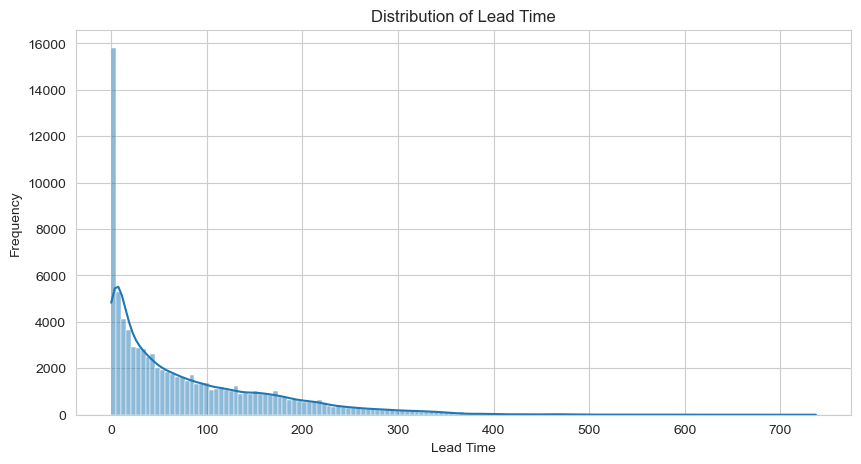

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(df['lead_time'],
             kde=True)

plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Frequency')

plt.show()

## Histogram and KDE Plot - Lead Time



### Findings

- Most bookings have relatively low lead times.
- Frequency decreases as lead time increases.
- A long tail extends toward very high lead times.
- Very few customers book more than 300 days in advance.

### Interpretation

The distribution is heavily right-skewed. Most customers book close to their arrival date, while a small number of customers make bookings far in advance.

### Normal Distribution Analysis

This distribution is not normal because:

- The curve is not symmetric.
- Mean (79.91) is greater than median (49).
- A long right tail is visible.
- Extreme values stretch the distribution.

### Business Insight

Hotels receive most bookings within a relatively short planning window. Marketing campaigns and pricing adjustments can therefore be focused on customers who book within the first few months before arrival.

### Conclusion

Lead time follows a positively skewed distribution and does not satisfy the characteristics of a normal distribution.

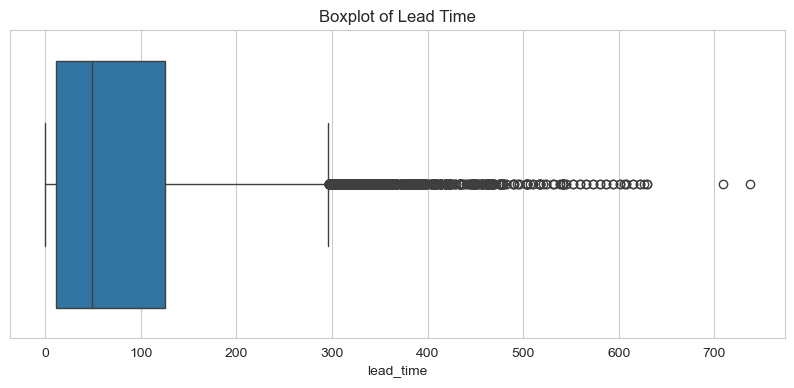

In [13]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['lead_time'])

plt.title('Boxplot of Lead Time')

plt.show()

## Boxplot Analysis - Lead Time

### Findings

- Median lead time is approximately 49 days.
- The central 50% of bookings lie between 11 and 125 days.
- A large number of observations appear beyond the upper whisker.
- Several extreme lead time values exceed 500 days.

### Interpretation

Many customers behave similarly and book within a reasonable time frame, but some customers make reservations extremely early, creating numerous outliers.

### Are These Outliers Errors?

No.

These values represent genuine customer booking behavior rather than data entry mistakes. Therefore, they should be retained for analysis.

### Business Insight

The existence of long-term planners indicates that hotels serve multiple customer segments, including customers who plan vacations or events far in advance.

### Conclusion

Lead time contains many legitimate outliers and shows substantial variability in customer booking behavior.

# ADR (Average Daily Rate) Analysis

## Why this Variable?

ADR represents the average revenue earned per occupied room per day. It is one of the most important business metrics in the hotel industry because it directly reflects pricing and revenue performance.

## Objective

To understand the distribution of room prices, identify pricing patterns, detect unusual values, and evaluate revenue-related customer behavior.

In [14]:
df['adr'].describe()

count    87370.000000
mean       106.346935
std         55.004259
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64

## ADR Analysis

### Use Case

ADR (Average Daily Rate) was analyzed to understand hotel pricing behavior and revenue characteristics. Since ADR directly affects hotel revenue, understanding its distribution helps identify pricing patterns and unusual pricing observations.

### Findings

* Average ADR is approximately 106.
* Most bookings have ADR values between 72 and 134.
* The median ADR is 98.1.
* ADR ranges from -6.38 to 5400.
* The maximum ADR is significantly higher than the typical booking price.

### Interpretation

The average room price is around 106, while most bookings fall within a much narrower range.

The mean is higher than the median, indicating that a small number of high ADR values are pulling the average upward.

This suggests that room prices are not evenly distributed across bookings.

### Special Observations

* ADR contains a negative value (-6.38), which is unusual and should be investigated further.
* ADR contains extremely large values, with a maximum of 5400.
* These extreme observations may represent luxury bookings, special pricing situations, or potential data quality issues.

### Business Insight

Most customers book rooms within a moderate price range, while a smaller segment contributes to significantly higher room revenue.

Understanding these premium-priced bookings can help hotels improve pricing strategies and revenue management.

### Conclusion

ADR shows substantial variation in room prices and contains extreme observations. Further visualization is required to understand the distribution pattern and determine whether the extreme values represent valid business cases or anomalies.


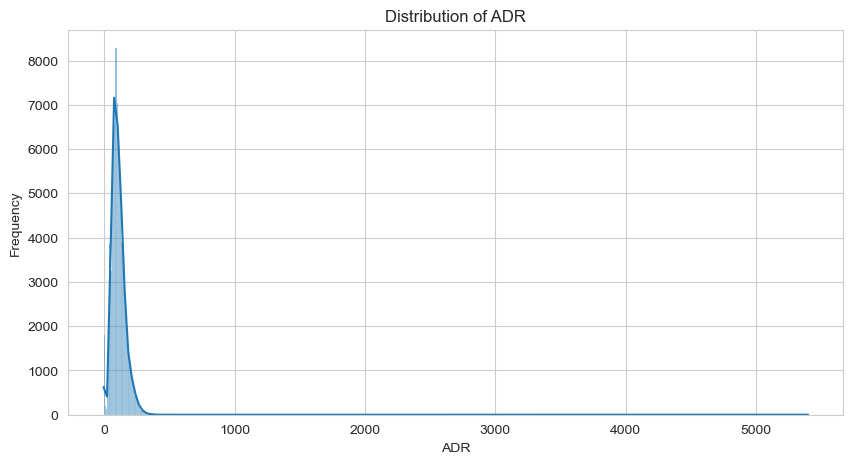

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['adr'], kde=True)

plt.title('Distribution of ADR')
plt.xlabel('ADR')
plt.ylabel('Frequency')

plt.show()

## Histogram and KDE Plot Analysis - ADR

### Use Case

Histogram and KDE plots were used to understand the distribution of ADR values and identify the overall pricing pattern followed by customers.

### Findings

* Most ADR values are concentrated within a relatively small range.
* Frequency decreases as ADR increases.
* The distribution has a long right tail.
* Very high ADR values occur rarely.

### Interpretation

The ADR distribution is positively skewed.

Most customers pay room prices within a moderate range, while a small number of customers pay exceptionally high room rates.

The mean ADR is higher than the median ADR, supporting the positive skewness observed in the visualization.

### Special Observations

* The distribution is not symmetric.
* ADR does not follow a normal distribution.
* A long right tail indicates the presence of high-priced bookings.
* Extreme ADR values significantly influence the distribution.

### Business Insight

Most hotel revenue comes from customers paying standard room rates, while a smaller segment contributes through premium-priced bookings.

### Conclusion

ADR follows a right-skewed distribution and does not exhibit characteristics of a normal distribution.


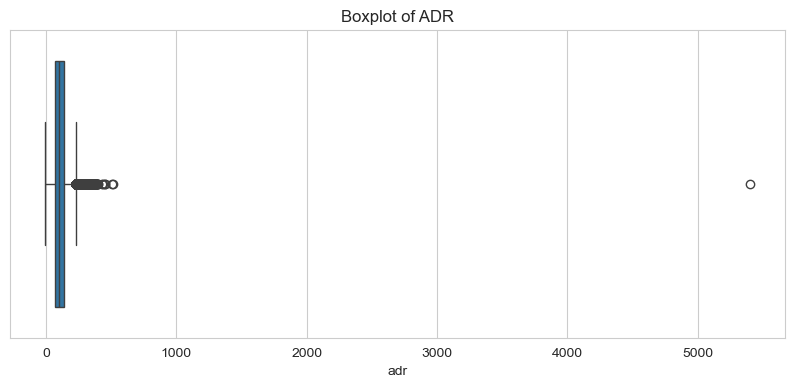

In [16]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['adr'])

plt.title('Boxplot of ADR')

plt.show()

## Boxplot Analysis - ADR

### Use Case

The boxplot was used to examine the spread of ADR values and identify potential outliers in hotel room pricing.

### Findings

* The majority of ADR values are concentrated within a relatively narrow range.
* Several observations lie beyond the upper whisker.
* One observation is extremely far from the rest of the dataset (ADR ≈ 5400).

### Interpretation

The boxplot confirms the presence of extreme ADR values.

Most room prices are clustered together, while a small number of bookings have unusually high ADR values.

### Special Observations

* Negative ADR values are present and should be investigated further.
* Extremely large ADR values exist in the dataset.
* These observations may represent luxury bookings, special events, pricing anomalies, or data quality issues.

### Outlier Analysis

The boxplot identifies statistical outliers.

However, these values should not be removed immediately because:

* Premium hotel rooms can legitimately have very high ADR values.
* Special occasions and peak-demand periods can increase room prices significantly.
* Outliers may contain important business information.

Further investigation is required before deciding whether these observations should be removed.

### Business Insight

The hotel serves different pricing segments, ranging from standard customers to premium customers who generate substantially higher revenue.

### Conclusion

ADR contains several statistical outliers and exhibits substantial variability in room pricing behavior.


# Adults Analysis

## Why this Variable?

The adults variable represents the number of adult guests included in a booking.

It is an important customer behavior variable because it helps understand booking composition, travel patterns, and customer demographics.

## Objective

To understand how many adults typically make hotel reservations, identify common booking patterns, and evaluate customer group composition.

## Business Importance

Understanding the number of adults per booking helps hotels optimize room allocation, service planning, occupancy management, and pricing strategies.

In [17]:
df['adults'].describe()

count    87370.000000
mean         1.875953
std          0.626473
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         55.000000
Name: adults, dtype: float64

## Descriptive Statistics Analysis

### Use Case

The `describe()` function was used to understand the distribution and booking composition of adult guests in hotel reservations.

### Findings

- Total bookings analyzed: 87,370
- Average number of adults per booking: 1.88
- Median number of adults per booking: 2
- Most bookings contain 2 adults.
- Adult counts range from 0 to 55.

### Interpretation

The average and median values indicate that hotel bookings are primarily made for one or two adults.

The 25th, 50th, and 75th percentiles are all equal to 2, showing that a large proportion of bookings contain exactly two adults.

This suggests that couples and small groups represent the dominant customer segment.

### Special Observations

- Some bookings contain 0 adults, which may represent data anomalies or bookings consisting only of children and babies.
- The maximum value of 55 adults is extremely high and likely represents group bookings or special reservation cases.

### Business Insight

The hotel mainly serves individual travelers and couples. However, the presence of large-group bookings indicates an additional customer segment that may require special accommodation and service planning.

### Conclusion

Most reservations are made by one or two adults, making small-party bookings the dominant pattern. A small number of large-group bookings create variation in the dataset and should be further examined through visualization.

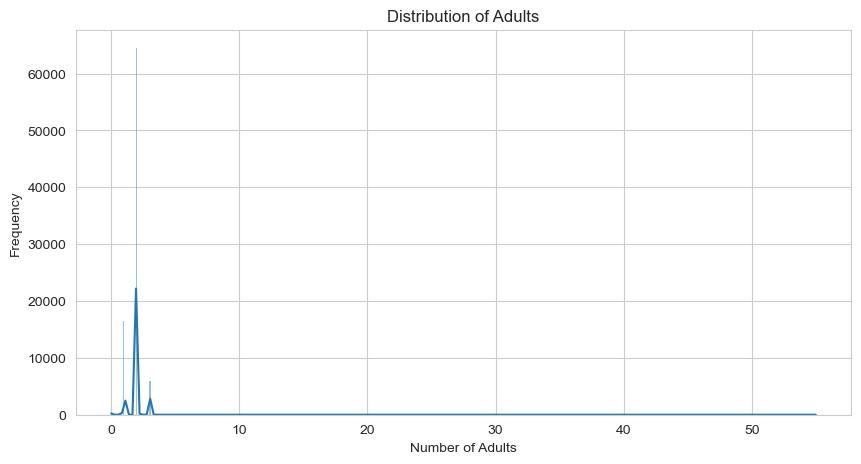

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df['adults'], kde=True)

plt.title('Distribution of Adults')
plt.xlabel('Number of Adults')
plt.ylabel('Frequency')

plt.show()

## Histogram and KDE Plot Analysis

### Why this Visualization?

Histogram and KDE plots were used to understand the distribution pattern of adult guests per booking and determine whether the data follows a normal distribution.

### Use Case

This visualization helps identify:

- Most common number of adults per booking
- Distribution shape
- Customer booking patterns
- Presence of skewness
- Unusual booking sizes

### Findings

- Most bookings contain 2 adults.
- Bookings with 1 adult are also common.
- Frequency drops sharply beyond 2 adults.
- Very large group bookings are rare.

### Interpretation

The distribution is concentrated around 1 and 2 adults, indicating that individual travelers and couples form the majority of hotel guests.

The distribution is not symmetric and contains a long right tail due to a small number of large-group bookings.

### Business Insight

The hotel primarily serves couples and small travel groups. Large-group reservations exist but represent only a small portion of total bookings.

### Conclusion

Adult guest counts are heavily concentrated around small booking sizes, and the distribution does not follow a normal distribution due to the presence of large-group bookings.

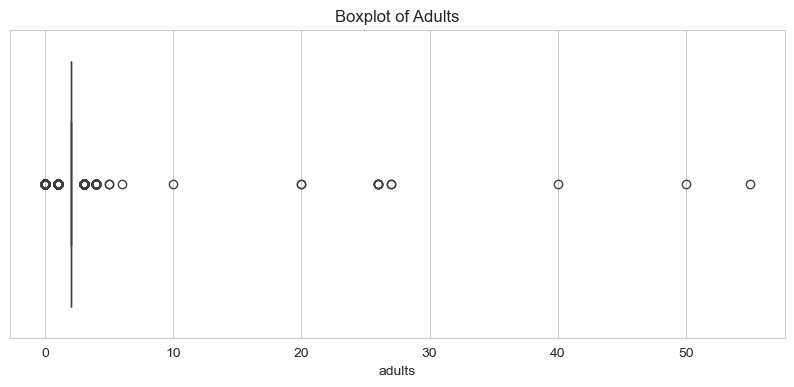

In [19]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['adults'])

plt.title('Boxplot of Adults')

plt.show()

## Boxplot Analysis

### Findings

- Most bookings are concentrated around 2 adults.
- The central spread of the data is very small.
- Several observations appear beyond the upper whisker.
- Adult counts extend up to 55 guests.

### Interpretation

The majority of reservations contain one or two adults, indicating that individual travelers and couples dominate the booking population.

A small number of bookings contain exceptionally large numbers of adults and are flagged as statistical outliers.

### Special Observations

Although the boxplot identifies these observations as outliers, they are likely genuine business cases rather than data errors.

Large values may represent:

- Group reservations
- Corporate bookings
- Tour groups
- Event-related bookings

Therefore, these observations should be retained because they represent valid customer segments.

### Business Insight

The hotel primarily serves small travel groups but also accommodates occasional large-group reservations that may require specialized services and room allocation strategies.

### Conclusion

Adult guest counts are highly concentrated around small booking sizes. While several statistical outliers exist, they appear to represent legitimate large-group bookings rather than data quality issues.

# Total Special Requests Analysis

## Why this Variable?

The total_of_special_requests variable represents the number of special requests made by customers during the booking process.

Examples include requests for preferred room location, additional services, special arrangements, and other customer preferences.

## Objective

To understand customer service expectations, identify booking behavior patterns, and analyze how frequently guests make special requests.

## Business Importance

Special requests provide valuable insights into customer expectations and service requirements. Understanding these requests helps hotels improve customer satisfaction, resource planning, and personalized service delivery.

In [21]:
df['total_of_special_requests'].describe()

count    87370.000000
mean         0.698638
std          0.831946
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: total_of_special_requests, dtype: float64


### Findings

- Total bookings analyzed: 87,370
- Average special requests per booking: 0.70
- Median special requests per booking: 0
- 75% of bookings contain at most 1 special request.
- The maximum number of special requests recorded is 5.

### Interpretation

The median value of 0 indicates that more than half of the customers do not make any special requests during booking.

The average value below 1 suggests that special requests are relatively uncommon and are usually limited to one request when they occur.

### Special Observations

- Most bookings contain either 0 or 1 special request.
- Only a small proportion of customers make multiple requests.
- The maximum value of 5 indicates that some guests have highly specific service requirements.

### Business Insight

Most customers follow a standard booking process without additional requirements. However, a smaller segment of guests expects personalized services, which can significantly influence customer satisfaction and service quality.

### Conclusion

Special requests are generally low across bookings, with most customers making no requests at all. A small group of customers demonstrates higher service expectations through multiple special requests.

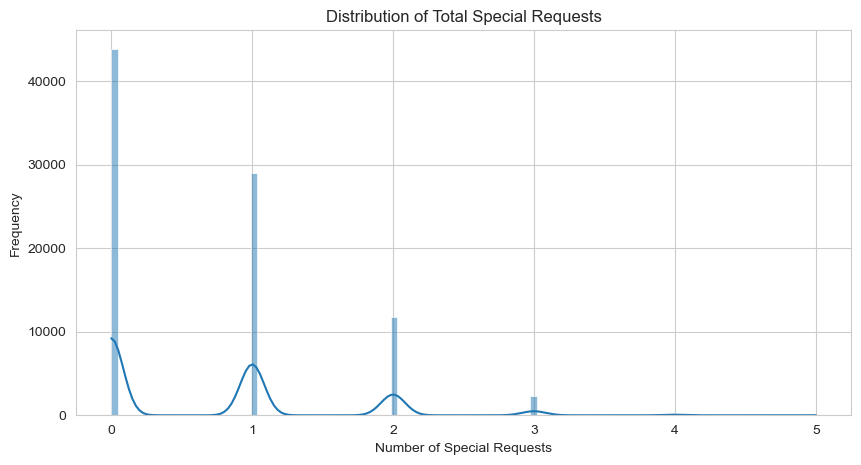

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(df['total_of_special_requests'], kde=True)

plt.title('Distribution of Total Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Frequency')

plt.show()


### Findings

- Most bookings contain 0 special requests.
- The frequency decreases as the number of requests increases.
- Bookings with 1 request are the second most common category.
- Very few customers make more than 2 special requests.

### Interpretation

The distribution is heavily concentrated at lower values, indicating that most customers complete their bookings without requesting additional services.

As the number of special requests increases, the frequency of bookings decreases significantly.

### Special Observations

- The highest concentration occurs at 0 requests.
- Multiple special requests are relatively rare.
- The distribution is positively skewed.

### Business Insight

Most guests follow a standard booking process without additional requirements. However, a smaller group of customers seeks personalized services, which can provide opportunities for improved guest satisfaction and premium service offerings.

### Conclusion

Special requests are generally low across bookings. The majority of customers make no requests, while only a small proportion require multiple personalized services.

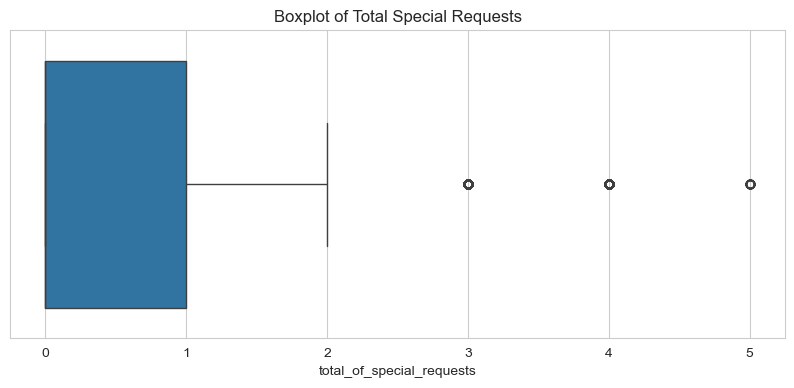

In [23]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['total_of_special_requests'])

plt.title('Boxplot of Total Special Requests')

plt.show()

## Boxplot Analysis

### Findings

- Most bookings contain between 0 and 1 special requests.
- The median number of requests is 0.
- Values above 2 requests appear as outliers.
- The maximum number of requests observed is 5.

### Interpretation

The majority of customers either make no requests or only one request during booking.

Customers making 3, 4, or 5 requests are relatively uncommon and differ from the typical booking pattern.

### Special Observations

Although these observations are identified as statistical outliers, they are likely genuine customer behaviors rather than data errors.

Guests may have multiple legitimate requirements such as:

- Room preferences
- Accessibility needs
- Special occasions
- Additional hotel services

Therefore, these values should be retained.

### Business Insight

A small group of customers demonstrates higher service expectations and may benefit from personalized guest experiences. Understanding these customers can help improve satisfaction and customer retention.

### Conclusion

Most bookings involve few or no special requests. While a small number of customers make multiple requests, these observations represent valuable business information and should not be treated as errors.

# Hotel Type Analysis

## Why this Variable?

The hotel variable identifies whether a booking belongs to a City Hotel or a Resort Hotel.

## Objective

To understand the distribution of bookings across hotel types and identify which hotel category receives the highest number of reservations.

## Business Importance

Hotel type influences customer behavior, pricing strategy, occupancy planning, marketing decisions, and operational management. Understanding hotel distribution helps identify the primary source of bookings.

In [24]:
df['hotel'].value_counts()

hotel
City Hotel      53426
Resort Hotel    33944
Name: count, dtype: int64

## Frequency Table Analysis

### Use Case

The `value_counts()` function was used to determine the number of bookings associated with each hotel type and understand the overall distribution of reservations.

### Findings

- City Hotel: 53,426 bookings
- Resort Hotel: 33,944 bookings

### Interpretation

City Hotels account for the majority of bookings in the dataset.

Approximately 61% of bookings belong to City Hotels, while about 39% belong to Resort Hotels.

This indicates that customers prefer City Hotels more frequently than Resort Hotels.

### Business Insight

The higher booking volume for City Hotels may be due to business travel, urban tourism, better accessibility, and year-round demand.

Resort Hotels still represent a significant portion of bookings and cater to customers seeking leisure and vacation experiences.

### Conclusion

City Hotels are the dominant hotel category in the dataset and contribute the largest share of reservations.

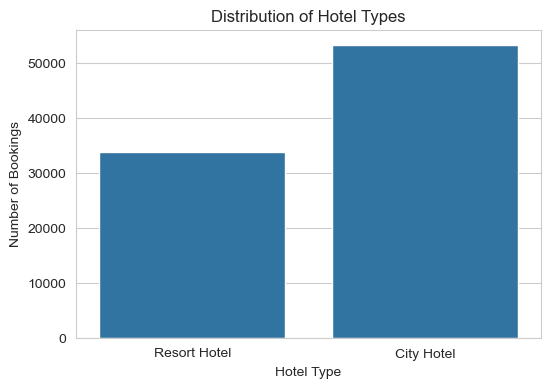

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x='hotel', data=df)

plt.title('Distribution of Hotel Types')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.show()

## Countplot Analysis

### Findings

- City Hotels have substantially more bookings than Resort Hotels.
- City Hotels account for the majority of reservations in the dataset.
- Resort Hotels contribute a significant but smaller share of total bookings.

### Interpretation

The higher bar for City Hotels indicates stronger customer demand compared to Resort Hotels.

This suggests that travelers are more likely to book accommodations in urban locations, possibly due to business travel, city tourism, accessibility, and year-round demand.

### Business Insight

Since City Hotels generate the largest booking volume, hotel management may prioritize marketing campaigns, resource allocation, staffing, and operational planning for this segment.

Resort Hotels remain an important market segment and may require targeted seasonal promotions to increase occupancy.

### Conclusion

The visualization confirms that City Hotels are the dominant hotel category in the dataset and represent the primary source of bookings.

# Market Segment Analysis

## Why this Variable?

The market_segment variable identifies the source through which a customer makes a booking, such as Online Travel Agencies (OTA), Direct bookings, Corporate bookings, and other channels.

## Objective

To understand the contribution of different booking channels and identify the most important sources of reservations.

## Business Importance

Understanding booking channels helps hotels optimize marketing strategies, distribution partnerships, customer acquisition efforts, and revenue management.

In [26]:
df['market_segment'].value_counts()

market_segment
Online TA        51615
Offline TA/TO    13886
Direct           11798
Groups            4940
Corporate         4202
Complementary      702
Aviation           227
Name: count, dtype: int64

## Frequency Table Analysis

### Use Case

The `value_counts()` function was used to determine the number of bookings generated through each market segment and identify the most important booking channels.

### Findings

- Online TA: 51,615 bookings
- Offline TA/TO: 13,886 bookings
- Direct: 11,798 bookings
- Groups: 4,940 bookings
- Corporate: 4,202 bookings
- Complementary: 702 bookings
- Aviation: 227 bookings

### Interpretation

Online Travel Agencies (OTA) contribute the highest number of bookings by a large margin.

Offline travel agencies and tour operators represent the second-largest booking source, followed closely by direct bookings.

Corporate, complementary, and aviation channels contribute a relatively small proportion of total reservations.

### Special Observations

- More than half of all bookings originate from Online Travel Agencies.
- Direct bookings are considerably lower than OTA bookings.
- Aviation and Complimentary bookings form only a small fraction of the dataset.

### Business Insight

The hotel business is heavily dependent on Online Travel Agencies for customer acquisition.

While OTAs provide high visibility and booking volume, increasing direct bookings could help reduce commission costs and improve profitability.

### Conclusion

Online Travel Agencies are the dominant booking channel in the dataset, making them a critical contributor to hotel revenue and occupancy.

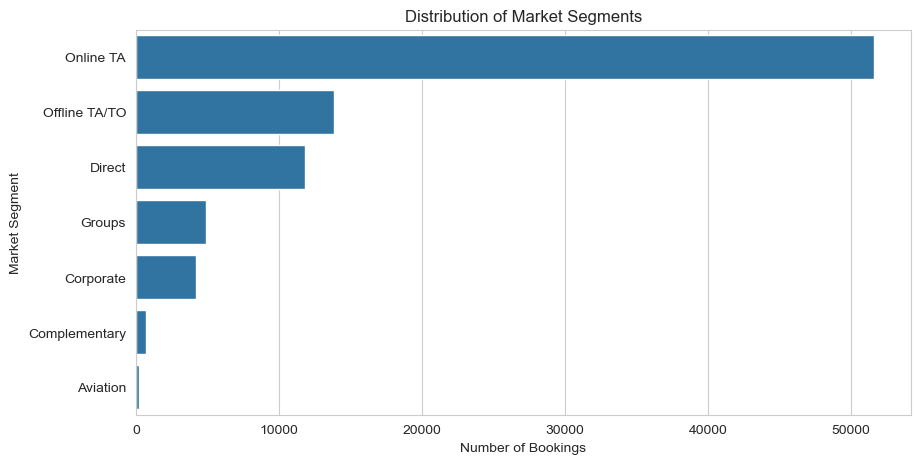

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='market_segment',
    data=df,
    order=df['market_segment'].value_counts().index
)

plt.title('Distribution of Market Segments')
plt.xlabel('Number of Bookings')
plt.ylabel('Market Segment')

plt.show()

## Countplot Analysis

### Why this Visualization?

The countplot was used to visually compare the number of bookings generated by each market segment and identify the most important booking channels.

### Use Case

This visualization helps:

- Compare booking volumes across different market segments.
- Identify dominant customer acquisition channels.
- Understand customer booking behavior.
- Support marketing and revenue management decisions.

### Findings

- Online TA is the dominant booking channel with the highest number of reservations.
- Offline TA/TO is the second-largest booking source.
- Direct bookings rank third.
- Groups and Corporate segments contribute a moderate number of bookings.
- Complimentary and Aviation segments account for only a small fraction of reservations.

### Interpretation

The large gap between Online TA and all other segments indicates a strong dependence on Online Travel Agencies for customer acquisition.

Traditional travel agencies and direct bookings continue to play an important role but contribute significantly fewer reservations.

### Special Observations

- Online TA alone contributes more bookings than several other segments combined.
- Direct bookings remain lower than OTA bookings.
- Aviation and Complimentary channels have minimal influence on total occupancy.

### Business Insight

The hotel relies heavily on Online Travel Agencies to generate bookings. While OTAs increase visibility and occupancy, dependence on third-party platforms may increase commission expenses.

Increasing direct bookings through loyalty programs, promotions, and digital marketing could improve profitability.

### Conclusion

Online Travel Agencies are the primary booking source and represent the most influential market segment in the dataset. Diversifying acquisition channels and increasing direct bookings may provide long-term business benefits.

# Customer Type Analysis

## Why this Variable?

The customer_type variable classifies guests based on their booking behavior and relationship with the hotel.

Different customer types may exhibit different booking patterns, service requirements, cancellation tendencies, and loyalty characteristics.

## Objective

To understand the distribution of customer categories and identify the dominant customer segment in the dataset.

## Business Importance

Customer segmentation is essential for personalized marketing, customer retention, service planning, and revenue optimization. Understanding the dominant customer types helps hotels design targeted strategies for different guest groups.

In [28]:
df['customer_type'].value_counts()

customer_type
Transient          71968
Transient-Party    11719
Contract            3139
Group                544
Name: count, dtype: int64

## Frequency Table Analysis

### Use Case

The `value_counts()` function was used to determine the number of bookings associated with each customer type and identify the dominant customer segment.

### Findings

- Transient: 71,968 bookings
- Transient-Party: 11,719 bookings
- Contract: 3,139 bookings
- Group: 544 bookings

### Interpretation

Transient customers represent the overwhelming majority of hotel bookings.

Transient-Party customers form the second-largest segment, while Contract and Group customers account for only a small proportion of reservations.

This indicates that the hotel primarily serves individual travelers rather than long-term contracted clients or organized groups.

### Special Observations

- More than 80% of bookings belong to the Transient category.
- Group bookings are extremely rare.
- Contract customers represent a niche customer segment.

### Business Insight

The hotel's revenue and occupancy are heavily dependent on transient guests. This suggests that customer acquisition strategies, pricing decisions, and service offerings should primarily focus on individual travelers and small travel parties.

### Conclusion

Transient customers dominate the dataset and represent the primary customer segment. Other customer types contribute comparatively fewer bookings and serve specialized market needs.

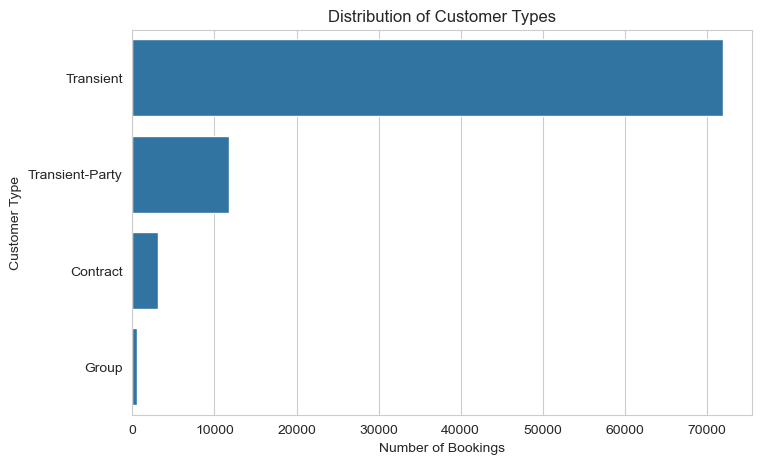

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='customer_type',
    data=df,
    order=df['customer_type'].value_counts().index
)

plt.title('Distribution of Customer Types')
plt.xlabel('Number of Bookings')
plt.ylabel('Customer Type')

plt.show()

## Countplot Analysis

### Why this Visualization?

The countplot was used to visually compare the number of bookings across different customer types and identify the dominant customer segment.

### Use Case

This visualization helps:

- Compare booking volumes among customer categories.
- Identify the primary customer segment.
- Understand customer distribution patterns.
- Support customer-focused business strategies.

### Findings

- Transient customers dominate the dataset.
- Transient-Party customers represent the second-largest segment.
- Contract customers contribute a relatively small number of bookings.
- Group customers account for only a very small proportion of reservations.

### Interpretation

The large difference between the Transient category and all other customer types indicates that the hotel primarily serves independent travelers.

Transient-Party customers also contribute significantly, suggesting that many guests travel in small parties rather than as part of organized groups.

### Special Observations

- The Transient segment overwhelmingly exceeds all other categories.
- Group bookings are extremely rare.
- Contract customers represent a niche business segment.

### Business Insight

Since most revenue is generated from transient guests, customer acquisition, pricing strategies, loyalty programs, and service offerings should focus primarily on individual travelers and small travel parties.

Hotels may also explore opportunities to increase contract and group bookings to diversify revenue sources.

### Conclusion

The customer base is heavily concentrated in the Transient segment, making individual travelers the most important customer group in the dataset.

# Deposit Type Analysis

## Why this Variable?

The deposit_type variable indicates the payment policy associated with a booking, such as No Deposit, Refundable Deposit, or Non-Refundable Deposit.

## Objective

To understand customer payment preferences and identify the most common deposit policies used during booking.

## Business Importance

Deposit policies influence customer commitment, cancellation behavior, revenue protection, and risk management. Understanding deposit patterns helps hotels optimize booking and payment strategies.

In [31]:
df['deposit_type'].value_counts()

deposit_type
No Deposit    86225
Non Refund     1038
Refundable      107
Name: count, dtype: int64

## Frequency Table Analysis

### Use Case

The `value_counts()` function was used to determine the number of bookings associated with each deposit policy and identify the most common payment commitment pattern among customers.

### Findings

* No Deposit: 86,225 bookings
* Non Refund: 1,038 bookings
* Refundable: 107 bookings

### Interpretation

The vast majority of customers make bookings without paying any deposit.

Non-refundable deposits are used by a very small number of customers, while refundable deposits are extremely rare.

This indicates that the hotel primarily operates with a flexible booking policy where customers can reserve rooms without making advance payments.

### Special Observations

* More than 98% of bookings fall under the "No Deposit" category.
* Refundable deposits represent only a tiny fraction of reservations.
* Non-refundable deposits are significantly more common than refundable deposits, but still account for a very small share of total bookings.

### Business Insight

The hotel's booking strategy appears to prioritize flexibility and customer convenience rather than requiring financial commitment at the time of booking.

While this approach may encourage more reservations, it could also increase exposure to booking cancellations.

### Conclusion

The booking process is overwhelmingly dominated by the No Deposit policy, indicating that most customers reserve rooms without any upfront payment commitment.


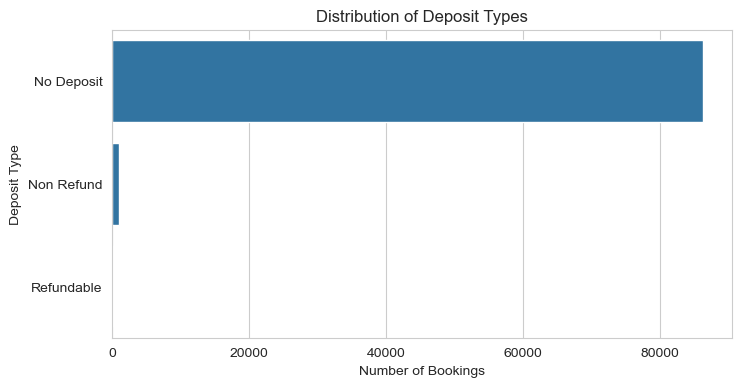

In [32]:
plt.figure(figsize=(8,4))

sns.countplot(
    y='deposit_type',
    data=df,
    order=df['deposit_type'].value_counts().index
)

plt.title('Distribution of Deposit Types')
plt.xlabel('Number of Bookings')
plt.ylabel('Deposit Type')

plt.show()

## Countplot Analysis

### Why this Visualization?

The countplot was used to visually compare booking volumes across different deposit policies and identify the most commonly used payment commitment method.

### Use Case

This visualization helps:

- Compare the popularity of different deposit policies.
- Understand customer payment preferences.
- Identify booking commitment patterns.
- Support revenue management and cancellation-risk analysis.

### Findings

- No Deposit overwhelmingly dominates the dataset.
- Non Refund bookings represent only a small fraction of reservations.
- Refundable deposits are extremely rare.

### Interpretation

The vast majority of customers prefer booking without making any advance deposit.

This suggests that customers value flexibility and are more likely to choose reservation options that do not require upfront payment.

### Special Observations

- The difference between No Deposit and the other deposit types is extremely large.
- Refundable deposits have almost no presence in the dataset.
- Non-refundable deposits are uncommon but are still more frequently used than refundable deposits.

### Business Insight

The hotel's booking system appears to prioritize convenience and accessibility by allowing customers to reserve rooms without financial commitment.

While this approach can increase booking volume, it may also expose the hotel to higher cancellation risk. Deposit policies therefore become particularly important when analyzing booking cancellations.

### Conclusion

No Deposit is by far the most preferred booking policy among customers. The visualization confirms that advance payment requirements are uncommon and that most reservations are made without any upfront financial commitment.

# Reserved Room Type Analysis

## Why this Variable?

The reserved_room_type variable represents the room category originally selected by customers during the booking process.

## Objective

To identify the most popular room categories and understand customer room preferences.

## Business Importance

Understanding room demand helps hotels optimize inventory management, pricing strategies, occupancy planning, and resource allocation.

In [33]:
df['reserved_room_type'].value_counts()

reserved_room_type
A    56530
D    17397
E     6047
F     2822
G     2052
B      999
C      915
H      596
L        6
P        6
Name: count, dtype: int64

## Frequency Table Analysis

### Use Case

The `value_counts()` function was used to determine the number of bookings associated with each reserved room type and identify the most frequently requested room categories.

### Findings

- Room Type A: 56,530 bookings
- Room Type D: 17,397 bookings
- Room Type E: 6,047 bookings
- Room Type F: 2,822 bookings
- Room Type G: 2,052 bookings
- Room Types B, C, and H have relatively low demand.
- Room Types L and P are extremely rare, with only 6 bookings each.

### Interpretation

Room Type A is overwhelmingly the most preferred room category and accounts for the majority of reservations.

Room Types D and E are the next most popular categories, while the remaining room types contribute a comparatively small share of bookings.

### Special Observations

- Room Type A alone represents a significant portion of total reservations.
- Demand decreases sharply after Room Types A and D.
- Room Types L and P are almost never booked.

### Business Insight

The hotel's occupancy and revenue are heavily influenced by demand for Room Type A.

Inventory planning, pricing strategies, and operational decisions should focus primarily on high-demand room categories while evaluating the necessity of maintaining rarely booked room types.

### Conclusion

Room Type A is the dominant room category in the dataset, indicating a strong customer preference for this room type. Demand for other room categories decreases substantially beyond the most popular options.

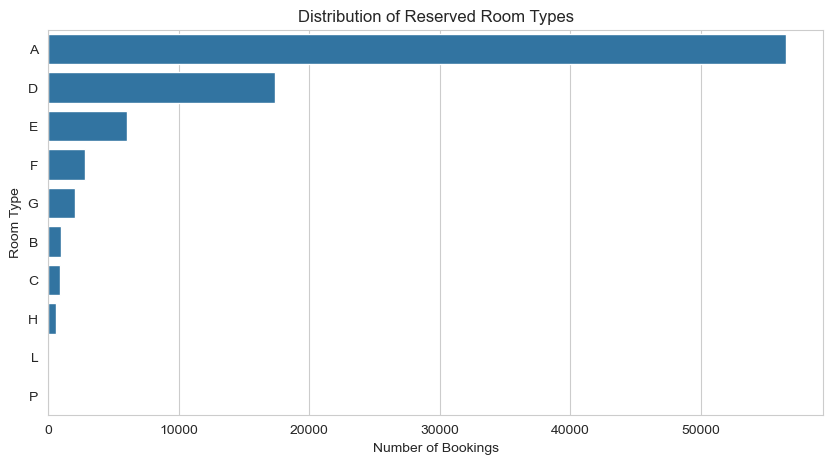

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='reserved_room_type',
    data=df,
    order=df['reserved_room_type'].value_counts().index
)

plt.title('Distribution of Reserved Room Types')
plt.xlabel('Number of Bookings')
plt.ylabel('Room Type')

plt.show()

## Countplot Analysis

### Why this Visualization?

The countplot was used to visually compare the popularity of different room categories and identify which room types contribute most to hotel bookings.

### Use Case

This visualization helps:

- Compare demand across room categories.
- Identify the most preferred room types.
- Support inventory and occupancy planning.
- Assist pricing and revenue management decisions.

### Findings

- Room Type A dominates all other room categories.
- Room Type D is the second most requested room type.
- Room Types E, F, and G show moderate demand.
- Room Types B, C, and H receive relatively few bookings.
- Room Types L and P are almost never reserved.

### Interpretation

The majority of customers prefer Room Type A, indicating that it best matches customer needs in terms of price, capacity, or amenities.

Demand decreases significantly after Room Types A and D, showing that customer preferences are concentrated in only a few room categories.

### Special Observations

- Room Type A receives more bookings than all other room types combined.
- Several room categories experience very low demand.
- Room Types L and P contribute almost nothing to overall occupancy.

### Business Insight

Since Room Type A generates the highest demand, hotels should ensure adequate availability and optimize pricing strategies for this category.

Low-demand room categories may require promotional offers, repositioning, or further analysis to understand their limited popularity.

### Conclusion

Room Type A is the most preferred room category and serves as the primary contributor to hotel occupancy. Customer demand is highly concentrated in a small number of room types.

# Meal Type Analysis

## Why this Variable?

The meal variable indicates the meal package selected by customers during booking.

## Objective

To understand customer dining preferences and identify the most commonly chosen meal plans.

## Business Importance

Meal plans influence food service operations, customer satisfaction, revenue generation, and resource planning within the hotel.

In [35]:
df['meal'].value_counts()

meal
BB    67955
SC     9971
HB     9084
FB      360
Name: count, dtype: int64

## Frequency Table Analysis

### Use Case

The `value_counts()` function was used to determine the popularity of different meal plans and identify customer dining preferences.

### Findings

- BB (Bed & Breakfast): 67,955 bookings
- SC (Self Catering): 9,971 bookings
- HB (Half Board): 9,084 bookings
- FB (Full Board): 360 bookings

### Interpretation

BB is the most preferred meal plan by a very large margin.

SC and HB have moderate demand and contribute a similar number of bookings.

FB is rarely selected by customers.

### Special Observations

- More than three-fourths of all bookings include the BB meal plan.
- SC and HB are considerably less popular than BB.
- Full Board demand is extremely low.

### Business Insight

Customers appear to prefer flexible meal options rather than comprehensive meal packages.

The popularity of BB suggests that guests value having breakfast included while maintaining flexibility for lunch and dinner arrangements.

### Conclusion

BB is the dominant meal plan in the dataset and represents the preferred dining option among hotel guests. More extensive meal packages such as Full Board have very limited demand.

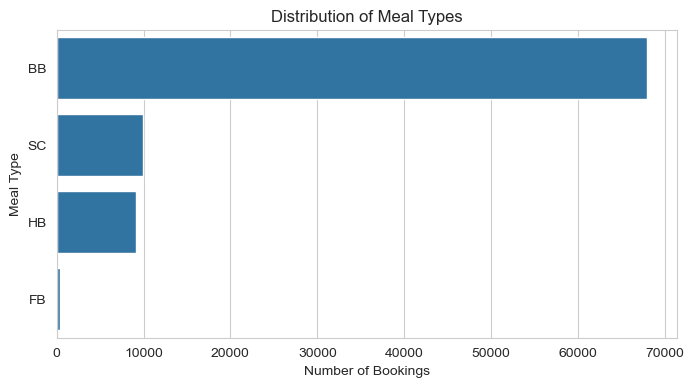

In [36]:
plt.figure(figsize=(8,4))

sns.countplot(
    y='meal',
    data=df,
    order=df['meal'].value_counts().index
)

plt.title('Distribution of Meal Types')
plt.xlabel('Number of Bookings')
plt.ylabel('Meal Type')

plt.show()

## Countplot Analysis

### Why this Visualization?

The countplot was used to visually compare the popularity of different meal plans and identify the most preferred dining package among hotel guests.


### Findings

- BB (Bed & Breakfast) overwhelmingly dominates all other meal plans.
- SC (Self Catering) and HB (Half Board) have moderate demand.
- FB (Full Board) has extremely low demand.

### Interpretation

Most customers prefer a meal package that includes breakfast only, while maintaining flexibility for lunch and dinner.

The relatively similar demand for SC and HB suggests that some guests either prefer complete flexibility or partial meal inclusion.

### Special Observations

- BB receives substantially more bookings than all other meal plans combined.
- Full Board is rarely selected by customers.
- Customer demand is highly concentrated in a single meal category.

### Business Insight

The popularity of BB indicates that breakfast is considered an important service by guests, while customers generally prefer flexibility for their remaining meals.

Hotels may focus resources on breakfast services while evaluating the profitability of less popular meal packages.

### Conclusion

BB is the dominant meal plan and represents the preferred dining option among hotel guests. Demand for more comprehensive meal packages remains limited.

# Distribution Channel Analysis

## Why this Variable?

The distribution_channel variable identifies the channel through which bookings are received, such as travel agencies, direct bookings, corporate channels, and other intermediaries.

## Objective

To understand how reservations reach the hotel and identify the most important booking distribution channels.

## Business Importance

Distribution channels influence customer acquisition costs, marketing effectiveness, booking volume, and revenue generation. Understanding these channels helps hotels optimize their sales and distribution strategies.

In [37]:
df['distribution_channel'].value_counts()

distribution_channel
TA/TO        69138
Direct       12980
Corporate     5071
GDS            181
Name: count, dtype: int64

## Frequency Table Analysis

### Use Case

The `value_counts()` function was used to determine the number of bookings received through each distribution channel and identify the most important reservation sources.

### Findings

- TA/TO (Travel Agents/Tour Operators): 69,138 bookings
- Direct: 12,980 bookings
- Corporate: 5,071 bookings
- GDS: 181 bookings

### Interpretation

TA/TO is the dominant distribution channel and contributes the majority of reservations.

Direct bookings represent the second-largest channel, while Corporate bookings contribute a smaller but meaningful share.

GDS bookings are extremely rare within the dataset.

### Special Observations

- Nearly four-fifths of all bookings originate from travel agents and tour operators.
- Direct bookings are substantially lower than TA/TO bookings.
- GDS contributes only a negligible number of reservations.

### Business Insight

The hotel is highly dependent on travel agencies and tour operators for customer acquisition.

Although these channels generate significant booking volume, increasing direct bookings could reduce commission expenses and improve profitability.

### Conclusion

TA/TO is the primary distribution channel and serves as the most important source of reservations. The hotel's booking ecosystem is strongly dependent on intermediary channels rather than direct customer bookings.

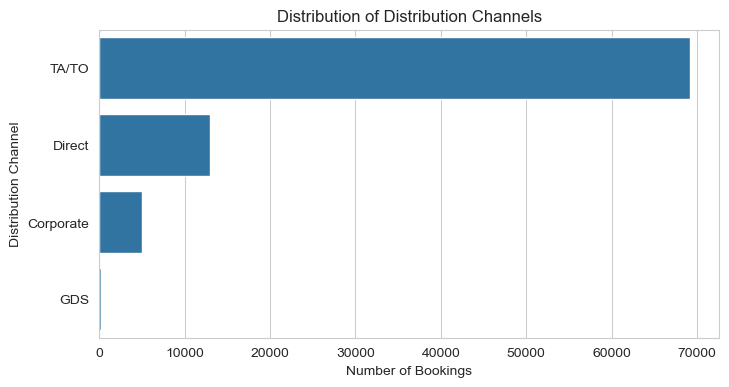

In [38]:
plt.figure(figsize=(8,4))

sns.countplot(
    y='distribution_channel',
    data=df,
    order=df['distribution_channel'].value_counts().index
)

plt.title('Distribution of Distribution Channels')
plt.xlabel('Number of Bookings')
plt.ylabel('Distribution Channel')

plt.show()

## Boxplot Analysis

### Why this Visualization?

The boxplot was used to examine the spread of special requests and identify customers who make unusually high numbers of requests compared to the majority of bookings.

### Use Case

The boxplot helps identify:

- Median number of special requests
- Data spread
- Interquartile Range (IQR)
- Statistical outliers
- Unusual customer behavior

### Findings

- Most bookings contain between 0 and 1 special requests.
- The median number of requests is 0.
- Values above 2 requests appear as outliers.
- The maximum number of requests observed is 5.

### Interpretation

The majority of customers either make no requests or only one request during booking.

Customers making 3, 4, or 5 requests are relatively uncommon and differ from the typical booking pattern.

### Special Observations

Although these observations are identified as statistical outliers, they are likely genuine customer behaviors rather than data errors.

Guests may have multiple legitimate requirements such as:

- Room preferences
- Accessibility needs
- Special occasions
- Additional hotel services

Therefore, these values should be retained.

### Business Insight

A small group of customers demonstrates higher service expectations and may benefit from personalized guest experiences. Understanding these customers can help improve satisfaction and customer retention.

### Conclusion

Most bookings involve few or no special requests. While a small number of customers make multiple requests, these observations represent valuable business information and should not be treated as errors.

# Reservation Status Analysis

## Why this Variable?

The reservation_status variable represents the final outcome of a booking, such as whether the reservation was completed, canceled, or resulted in a no-show.

## Objective

To understand the distribution of booking outcomes and identify the most common reservation status.

## Business Importance

Reservation status directly impacts hotel occupancy, revenue generation, and operational planning. Understanding booking outcomes helps evaluate customer behavior and supports cancellation analysis.

In [40]:
df['reservation_status'].value_counts()

reservation_status
Check-Out    63346
Canceled     23010
No-Show       1014
Name: count, dtype: int64

## Frequency Table Analysis

### Use Case

The `value_counts()` function was used to determine the number of bookings associated with each reservation outcome and identify the most common booking status.

### Findings

- Check-Out: 63,346 bookings
- Canceled: 23,010 bookings
- No-Show: 1,014 bookings

### Interpretation

Most reservations successfully resulted in guest check-outs, indicating that the majority of customers completed their bookings.

However, a substantial number of reservations were canceled before arrival.

No-show cases are relatively rare compared to completed and canceled bookings.

### Special Observations

- Check-Out is the dominant reservation outcome.
- More than twenty thousand bookings were canceled.
- No-show bookings represent only a small fraction of total reservations.

### Business Insight

Although most bookings are completed successfully, cancellations represent a significant loss of potential revenue and occupancy.

Understanding the factors influencing cancellations will be important in later bivariate analysis and predictive modeling.

### Conclusion

Check-Out is the most common reservation outcome, while cancellations remain a major business concern that requires further investigation.

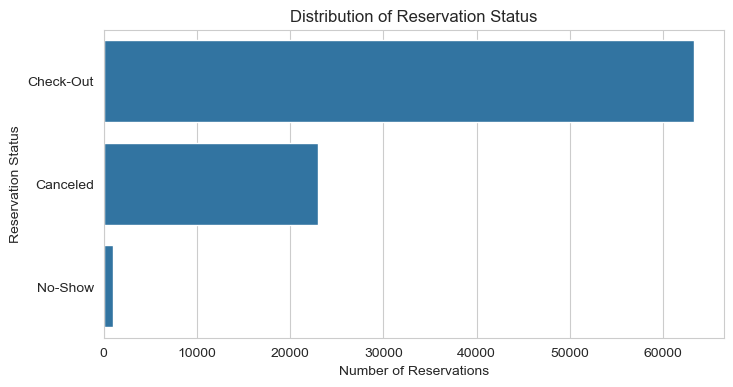

In [41]:
plt.figure(figsize=(8,4))

sns.countplot(
    y='reservation_status',
    data=df,
    order=df['reservation_status'].value_counts().index
)

plt.title('Distribution of Reservation Status')
plt.xlabel('Number of Reservations')
plt.ylabel('Reservation Status')

plt.show()

## Countplot Analysis

### Why this Visualization?

The countplot was used to visually compare reservation outcomes and identify the most common booking status.

### Use Case

This visualization helps:

- Compare booking outcomes.
- Measure cancellation impact.
- Evaluate operational performance.
- Support occupancy and revenue analysis.

### Findings

- Check-Out is the most common reservation outcome.
- Canceled bookings represent a significant portion of reservations.
- No-Show cases are relatively rare.

### Interpretation

Most customers successfully complete their reservations and check out of the hotel.

However, a considerable number of bookings are canceled before arrival, indicating that cancellation behavior is an important aspect of customer booking patterns.

### Special Observations

- Check-Out dominates the dataset.
- Cancellations represent a substantial loss of potential occupancy.
- No-Show incidents occur far less frequently than cancellations.

### Business Insight

Although the hotel successfully converts most reservations into completed stays, cancellation management remains a critical business challenge.

Reducing cancellations could significantly improve occupancy rates and revenue performance.

### Conclusion

Check-Out is the dominant reservation outcome, while cancellations remain an important factor that requires further investigation.

# Bivariate Analysis

## Objective

Bivariate Analysis is performed to study the relationship between two variables and identify patterns, dependencies, and business insights that cannot be observed through univariate analysis alone.

## Business Importance

Understanding relationships between variables helps explain customer behavior, pricing strategies, booking patterns, and operational performance. These insights support data-driven decision-making and future predictive modeling.

# Lead Time vs ADR Analysis

## Why These Variables?

Lead Time represents the number of days between booking and arrival, while ADR (Average Daily Rate) represents the average revenue earned per occupied room.

Analyzing these variables together helps determine whether booking timing influences room pricing.

## Objective

To investigate the relationship between booking lead time and room rates.

## Business Importance

Understanding this relationship helps hotels optimize pricing strategies, forecast demand, and improve revenue management decisions.

## Expected Insight

If a relationship exists between Lead Time and ADR, hotels can better understand whether early bookings or last-minute bookings are associated with higher room prices.

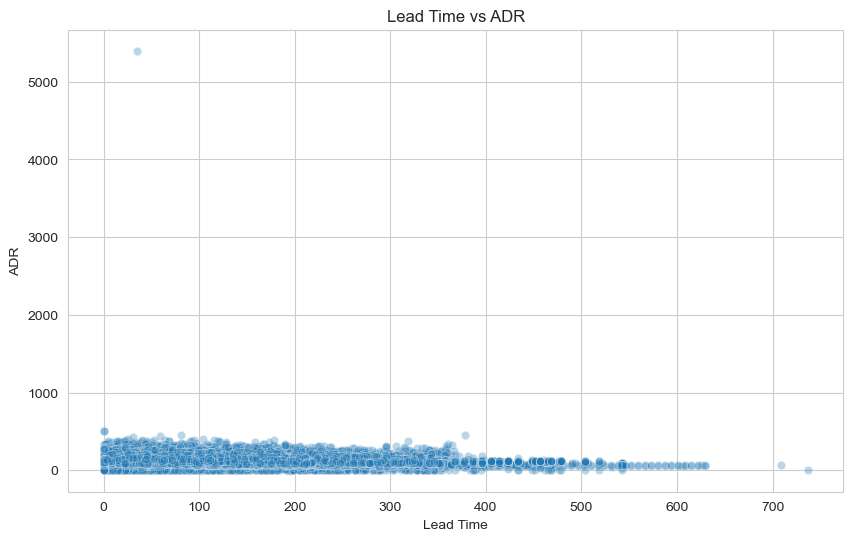

In [42]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='lead_time',
    y='adr',
    data=df,
    alpha=0.3
)

plt.title('Lead Time vs ADR')
plt.xlabel('Lead Time')
plt.ylabel('ADR')

plt.show()

## Scatterplot Analysis

### Why this Visualization?

A scatterplot was used to examine the relationship between Lead Time and ADR by plotting each booking as an individual observation.

### Use Case

This visualization helps:

- Identify relationships between booking timing and room pricing.
- Detect trends, clusters, and unusual observations.
- Understand whether customers booking earlier or later tend to pay different room rates.
- Support pricing and revenue management analysis.

### Findings

- Most bookings are concentrated below an ADR of 300.
- Lead Time ranges from 0 to over 700 days.
- The majority of observations are densely clustered in the lower ADR region.
- No clear upward or downward pattern is visible across the dataset.
- A few extremely high ADR observations are present.

### Interpretation

The scatterplot suggests a weak relationship between Lead Time and ADR. Customers who book far in advance do not consistently pay higher or lower room rates compared to customers who book closer to their arrival date.

The wide spread of ADR values across different lead times indicates that room pricing is likely influenced by additional factors beyond booking timing.

### Special Observations

- One extreme ADR value above 5000 is visible.
- Most ADR values remain below 300 regardless of Lead Time.
- The data points are heavily concentrated near the lower ADR range.
- No strong linear trend can be visually observed.

### Business Insight

Lead Time alone does not appear to be a strong driver of room pricing. Hotels may rely more on factors such as hotel type, customer segment, seasonality, room type, and demand conditions when determining ADR.

### Conclusion

The relationship between Lead Time and ADR appears weak. Booking earlier does not necessarily result in significantly different room prices, suggesting that ADR is influenced by multiple business factors rather than Lead Time alone.

In [43]:
df[['lead_time','adr']].corr()

,lead_time,adr
lead_time,1.000000,0.023412
adr,0.023412,1.000000


### Correlation Analysis

A correlation coefficient was calculated to quantify the relationship between Lead Time and ADR.

Correlation (r) = 0.0234

### Interpretation

The correlation value is extremely close to zero, indicating almost no linear relationship between Lead Time and ADR.

This confirms the pattern observed in the scatterplot, where no clear trend was visible between booking timing and room pricing.

### Business Insight

Lead Time alone is not a significant predictor of ADR. Room pricing is likely influenced by other factors such as hotel type, customer segment, room category, seasonality, and demand conditions.

### Conclusion

Both the scatterplot and correlation analysis indicate that Lead Time and ADR have a very weak relationship. Therefore, booking earlier or later does not significantly affect the average room rate paid by customers.

# ADR vs Total Special Requests Analysis

## Why These Variables?

ADR represents the average revenue earned per occupied room, while Total Special Requests measures the number of special requests made by guests during booking.

Analyzing these variables together helps determine whether guests paying higher room rates tend to request more services or personalized accommodations.

## Objective

To investigate the relationship between room pricing and customer special requests.

## Business Importance

Understanding this relationship helps hotels identify premium customer behavior and improve service planning and customer satisfaction strategies.

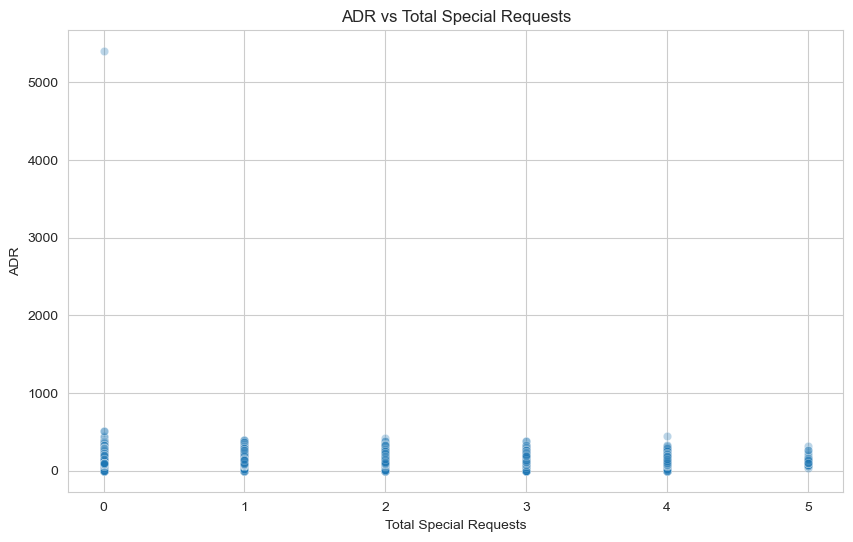

In [44]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='total_of_special_requests',
    y='adr',
    data=df,
    alpha=0.3
)

plt.title('ADR vs Total Special Requests')
plt.xlabel('Total Special Requests')
plt.ylabel('ADR')

plt.show()


### Findings

- Most ADR values are concentrated below 300 across all special request categories.
- Special requests range from 0 to 5.
- The majority of bookings contain 0 or 1 special request.
- ADR values are spread across all request categories.
- One extreme ADR outlier above 5000 is visible.

### Interpretation

The scatterplot does not show a strong relationship between ADR and the number of special requests.

Customers paying higher room rates do not consistently make more special requests than customers paying lower room rates.

### Special Observations

- The highest concentration of bookings occurs at 0 and 1 special requests.
- ADR variability exists within every special request category.
- The extreme ADR value appears to be an unusual booking and does not represent the general pattern.

### Business Insight

Special requests alone do not appear to be a strong indicator of customer spending behavior. Guests paying premium rates and guests paying standard rates both exhibit similar special request patterns.

Hotels should consider additional factors such as room type, customer segment, and hotel category when identifying high-value customers.

### Conclusion

The relationship between ADR and Total Special Requests appears weak. The number of special requests made by guests does not significantly influence the average room rate paid.

In [45]:
df[['total_of_special_requests', 'adr']].corr()

,total_of_special_requests,adr
total_of_special_requests,1.000000,0.137625
adr,0.137625,1.000000


### Correlation Analysis

A correlation coefficient was calculated to quantify the relationship between Total Special Requests and ADR.

Correlation (r) = 0.1376

### Interpretation

The correlation is positive but weak, indicating that customers who make more special requests tend to pay slightly higher room rates.

However, the relationship is not strong enough to conclude that special requests are a major driver of ADR.

### Business Insight

Guests making additional requests may represent slightly higher-value customers, but room pricing is primarily influenced by other factors such as room type, hotel category, market segment, and seasonal demand.

### Conclusion

The scatterplot and correlation analysis both suggest a weak positive relationship between Total Special Requests and ADR. Customers making more requests tend to pay marginally higher room rates, but the effect is relatively small.

# Correlation Heatmap Analysis

## Why this Analysis?

While scatterplots help analyze relationships between two variables at a time, a correlation heatmap provides a complete overview of relationships among all numerical variables in the dataset.

## Objective

To identify positive, negative, and weak relationships between numerical features and discover variables that may influence hotel booking behavior.

## Business Importance

Understanding correlations helps uncover hidden patterns, supports feature selection for future predictive models, and provides deeper insights into customer and booking characteristics.

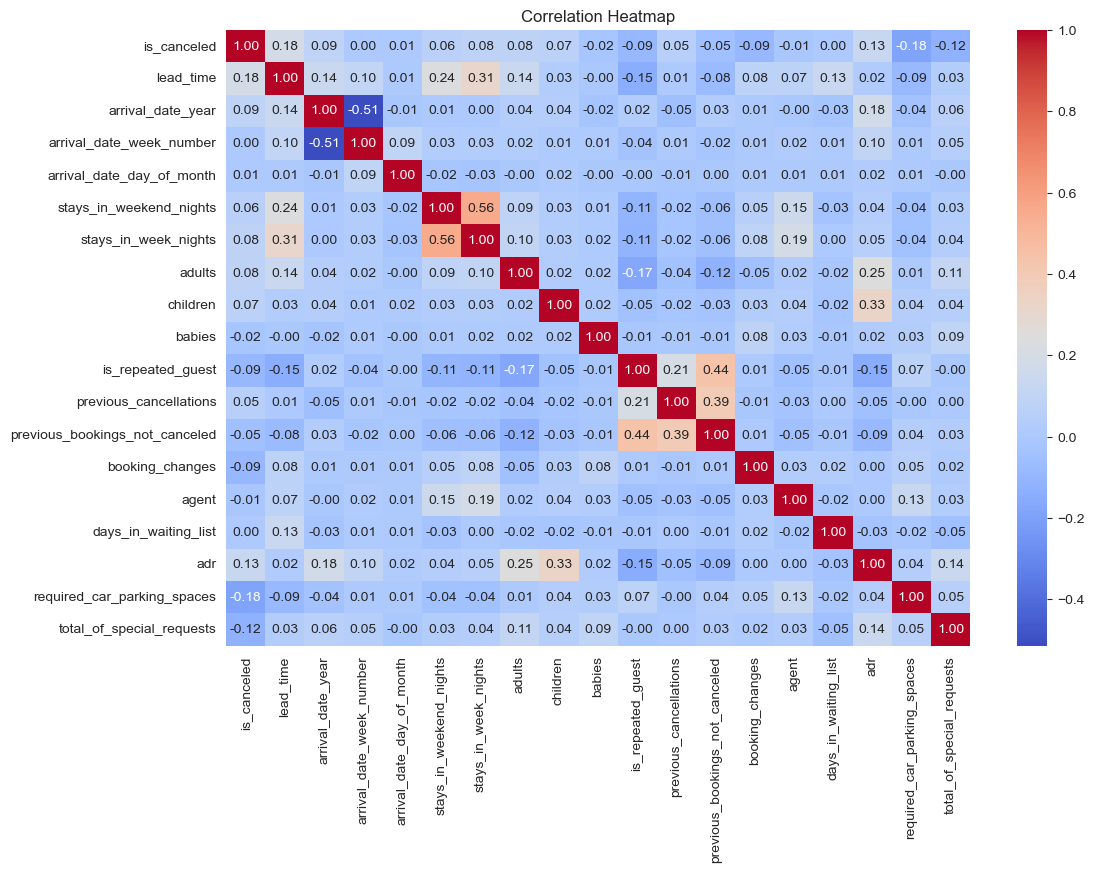

In [46]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

# Correlation Heatmap Analysis

## Why this Analysis?

A correlation heatmap was used to examine the relationships among all numerical variables in the hotel booking dataset simultaneously.

Unlike scatterplots, which analyze only two variables at a time, a heatmap provides a complete overview of how numerical features interact with one another.

## Objective

To identify positive, negative, and weak relationships between numerical variables and discover factors that may influence booking behavior, customer characteristics, and hotel performance.

## Business Importance

Understanding correlations helps:

- Discover hidden patterns in the dataset.
- Identify variables that move together.
- Support feature selection for predictive modeling.
- Provide insights into customer behavior and booking trends.

## Understanding Correlation Values

Correlation values range from -1 to +1.

- +1 → Perfect positive relationship
- 0 → No relationship
- -1 → Perfect negative relationship

General interpretation:

- 0.00 to 0.19 → Very Weak
- 0.20 to 0.39 → Weak
- 0.40 to 0.59 → Moderate
- 0.60 to 0.79 → Strong
- 0.80 to 1.00 → Very Strong

## Key Findings

### 1. Stays in Weekend Nights vs Stays in Week Nights

Correlation = 0.56

This is the strongest positive relationship in the dataset.

Guests who stay more weekday nights also tend to stay more weekend nights.

### 2. Previous Bookings Not Canceled vs Repeated Guest

Correlation = 0.44

Repeated guests are more likely to have a history of successful bookings.

This indicates customer loyalty and repeat business behavior.

### 3. Previous Cancellations vs Previous Bookings Not Canceled

Correlation = 0.39

Customers with more booking history tend to have both successful and canceled bookings recorded.

### 4. ADR vs Children

Correlation = 0.33

Families traveling with children tend to pay slightly higher room rates.

### 5. ADR vs Adults

Correlation = 0.25

Bookings with more adults generally show slightly higher ADR values.

### 6. Lead Time vs Week Night Stays

Correlation = 0.31

Customers booking earlier tend to stay slightly longer.

### 7. Lead Time vs ADR

Correlation = 0.02

Almost no relationship exists between booking timing and room price.

This confirms the scatterplot analysis performed earlier.

### 8. Total Special Requests vs ADR

Correlation = 0.14

A weak positive relationship exists.

Customers making more special requests tend to pay slightly higher room rates.

### 9. Required Car Parking Spaces vs Is Canceled

Correlation = -0.18

Customers requesting parking are slightly less likely to cancel their bookings.

## Special Observations

- Most correlations are weak.
- No pair of variables shows extremely high correlation.
- Multicollinearity is not a major concern in this dataset.
- Customer behavior appears to be influenced by multiple factors rather than a single dominant variable.

## Business Insights

- Longer stays often include both weekday and weekend nights.
- Repeat guests show stronger booking reliability.
- Families and larger groups tend to generate slightly higher revenue.
- Booking timing alone has little impact on room pricing.
- Special requests are weak indicators of premium customers.

## Conclusion

The correlation heatmap reveals that most numerical variables have weak to moderate relationships. The strongest relationship exists between weekday and weekend stay durations, while variables such as ADR, Lead Time, and Special Requests show only limited associations. This suggests that hotel booking behavior is influenced by multiple interacting factors rather than any single variable.

# Numeric–Categorical Analysis

## Why this Analysis?

Numeric–Categorical Analysis is used to understand how a numerical variable behaves across different categories.

While Numeric–Numeric Analysis studies relationships between two numerical variables, Numeric–Categorical Analysis compares numerical distributions among different groups.

## Objective

To identify differences in customer behavior, pricing patterns, booking characteristics, and hotel performance across categories.

## Business Importance

This analysis helps hotels identify profitable customer segments, evaluate pricing strategies, compare booking patterns, and support data-driven business decisions.

# ADR vs Hotel Type Analysis

## Why These Variables?

ADR (Average Daily Rate) represents the average revenue earned per occupied room and is one of the most important performance metrics in the hotel industry.

Hotel Type categorizes bookings into City Hotels and Resort Hotels.

Analyzing these variables together helps determine whether pricing strategies and revenue patterns differ across hotel categories.

## Objective

To compare ADR distributions between City Hotels and Resort Hotels and identify differences in room pricing behavior.

## Business Importance

Understanding ADR variations across hotel types helps:

* Evaluate pricing strategies.
* Identify high-revenue hotel categories.
* Understand customer spending patterns.
* Support revenue management and business planning.

## Expected Insight

If one hotel type consistently exhibits higher ADR values, it may indicate stronger pricing power, different customer demand patterns, or differences in services and amenities offered.


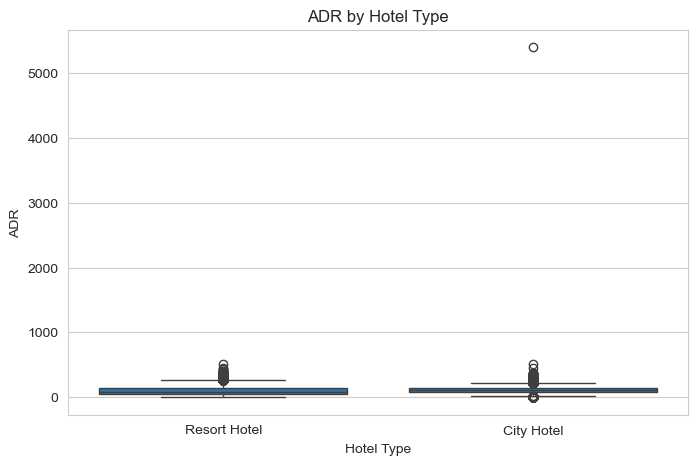

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='hotel',
    y='adr',
    data=df
)

plt.title('ADR by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('ADR')

plt.show()

## Boxplot Analysis


### Findings

* Both hotel types have similar ADR distributions.
* City Hotels show a slightly higher median ADR than Resort Hotels.
* The spread of ADR values is relatively similar for both hotel categories.
* Several high ADR observations are present in both hotel types.
* One extremely high ADR value (above 5000) is visible for City Hotels.

### Interpretation

The median ADR for City Hotels appears slightly higher than that of Resort Hotels, suggesting that City Hotels generally charge marginally higher room rates.

The interquartile ranges (IQRs) of both hotel types are comparable, indicating similar pricing variability.

Most bookings for both hotel categories are concentrated within a similar ADR range.

### Special Observations

* A very large ADR outlier exists for City Hotels.
* Multiple high-value ADR observations are visible in both hotel categories.
* The extreme ADR values represent rare bookings and do not reflect typical customer behavior.
* These observations should be treated as genuine business records unless data validation suggests otherwise.

### Business Insight

Both hotel categories follow similar pricing structures, although City Hotels appear to generate slightly higher room revenue on average.

The presence of premium ADR bookings suggests opportunities for revenue optimization and premium service offerings.

### Conclusion

ADR distributions are broadly similar across hotel types, with City Hotels showing a slightly higher typical room rate. Hotel type influences pricing to some extent, but the difference is not substantial.


# Lead Time vs Hotel Type Analysis

## Why These Variables?

Lead Time represents the number of days between booking and arrival, while Hotel Type categorizes bookings into City Hotels and Resort Hotels.

Analyzing these variables together helps understand whether customers of different hotel types exhibit different booking behaviors.

## Objective

To compare booking lead times between City Hotels and Resort Hotels and identify differences in customer planning behavior.

## Business Importance

Understanding lead time patterns helps hotels:

* Improve demand forecasting.
* Optimize pricing strategies.
* Plan marketing campaigns.
* Improve occupancy management.
* Anticipate customer booking behavior.

## Expected Insight

If one hotel type consistently shows higher lead times, it suggests that customers tend to plan those stays further in advance.


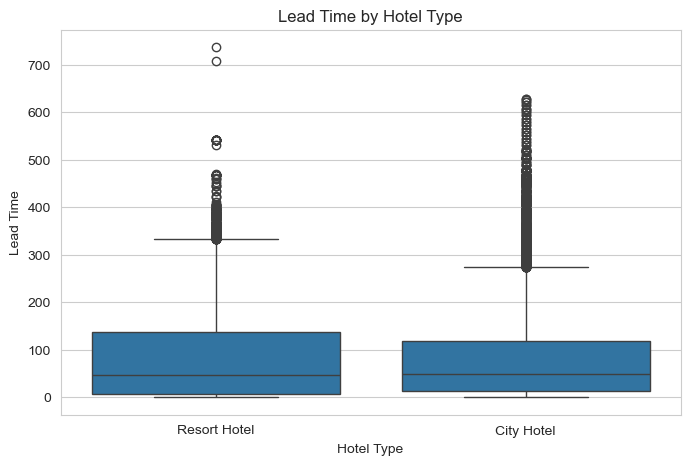

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='hotel',
    y='lead_time',
    data=df
)

plt.title('Lead Time by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Lead Time')

plt.show()

## Boxplot Analysis

### Why this Visualization?

A boxplot was used to compare the distribution of Lead Time across different hotel types and identify differences in booking behavior, spread, median values, and unusual observations.

### Findings

* The median Lead Time is slightly higher for City Hotels than for Resort Hotels.
* Both hotel types show a wide range of booking lead times.
* A large number of high Lead Time observations are present in both categories.
* Resort Hotels contain the highest observed Lead Time values, exceeding 700 days.

### Interpretation

Customers booking City Hotels tend to book slightly earlier on average compared to Resort Hotel customers.

However, the distributions of both hotel types are broadly similar, indicating comparable booking behavior across the two categories.

The large number of observations beyond the upper whiskers suggests that some customers plan their stays far in advance.

### Special Observations

* Many high Lead Time values appear as outliers.
* These observations are likely genuine bookings rather than data errors because advance bookings are common in the hotel industry.
* Resort Hotels contain the most extreme advance bookings.
* The presence of many such observations indicates that long-term planning is an important aspect of hotel booking behavior.

### Business Insight

Hotels should consider that a portion of customers make reservations several months in advance.

This information can support demand forecasting, inventory planning, pricing strategies, and promotional campaigns.

### Conclusion

Lead Time distributions are similar across hotel types, although City Hotels show a slightly higher median booking lead time. Both hotel categories receive a substantial number of advance bookings, highlighting the importance of long-term reservation planning.


# ADR vs Market Segment Analysis

## Why These Variables?

ADR represents the average revenue earned per occupied room, while Market Segment identifies the source or category of customers making bookings.

Analyzing these variables together helps determine which customer segments generate higher room revenue.

## Objective

To compare ADR across different market segments and identify the most valuable customer groups.

## Business Importance

Understanding revenue differences among market segments helps hotels:

* Identify profitable customer groups.
* Improve pricing strategies.
* Optimize marketing investments.
* Focus on high-value booking channels.

## Expected Insight

Some market segments may consistently generate higher ADR values, indicating stronger revenue potential and customer value.


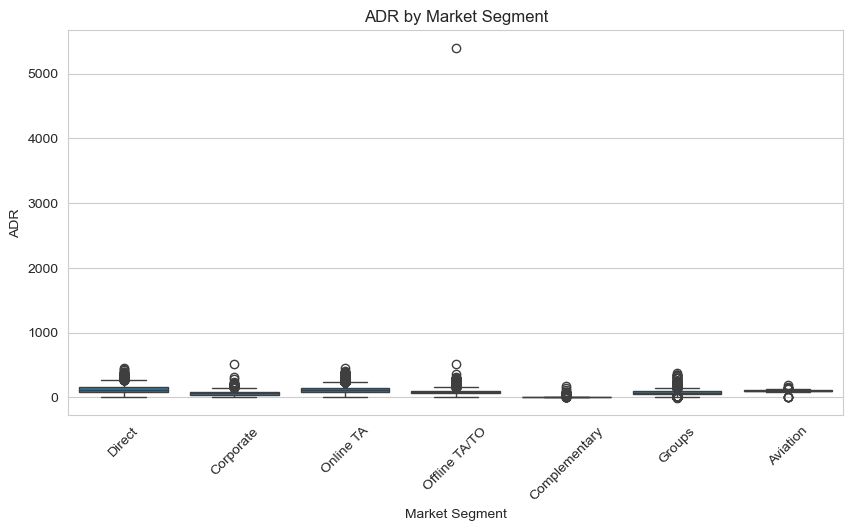

In [49]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='market_segment',
    y='adr',
    data=df
)

plt.xticks(rotation=45)

plt.title('ADR by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('ADR')

plt.show()

## Boxplot Analysis

### Why this Visualization?

A boxplot was used to compare ADR distributions across different market segments and identify differences in room pricing, revenue patterns, variability, and unusual observations.

### Findings

* ADR distributions differ across market segments.
* Direct, Online TA, and Aviation segments show relatively higher median ADR values.
* Corporate and Complementary segments generally exhibit lower ADR values.
* Several market segments contain high ADR observations.
* An extremely large ADR outlier is visible in the Offline TA/TO segment.

### Interpretation

Different market segments contribute differently to hotel revenue.

Segments such as Direct and Online TA appear to generate higher room rates, suggesting stronger revenue potential.

Corporate and Complementary bookings tend to be associated with lower room rates, likely reflecting negotiated contracts, discounts, or special arrangements.

### Special Observations

* A very large ADR outlier (>5000) appears in the Offline TA/TO segment.
* Most market segments contain genuine high-value bookings.
* The variability of ADR differs across customer groups.
* The outlier should not be used to represent typical customer behavior.

### Business Insight

Market Segment is an important factor influencing room pricing.

Hotels can use this information to:

* Focus marketing efforts on high-value segments.
* Improve revenue management strategies.
* Optimize promotional campaigns for lower-performing segments.

### Conclusion

ADR varies across market segments, indicating that customer source plays a meaningful role in hotel revenue generation. Some segments consistently generate higher room rates and may represent more valuable customer groups.


# ADR vs Customer Type Analysis

## Why These Variables?

ADR represents the average revenue earned per occupied room, while Customer Type categorizes guests based on their booking behavior.

Analyzing these variables together helps determine whether certain customer groups contribute more revenue than others.

## Objective

To compare ADR distributions across different customer types and identify the most valuable customer groups.

## Business Importance

Understanding revenue differences among customer types helps hotels:

* Identify profitable customer segments.
* Improve customer targeting strategies.
* Support revenue optimization.
* Enhance customer relationship management.

## Expected Insight

Different customer types may exhibit distinct spending patterns, resulting in variations in ADR across groups.


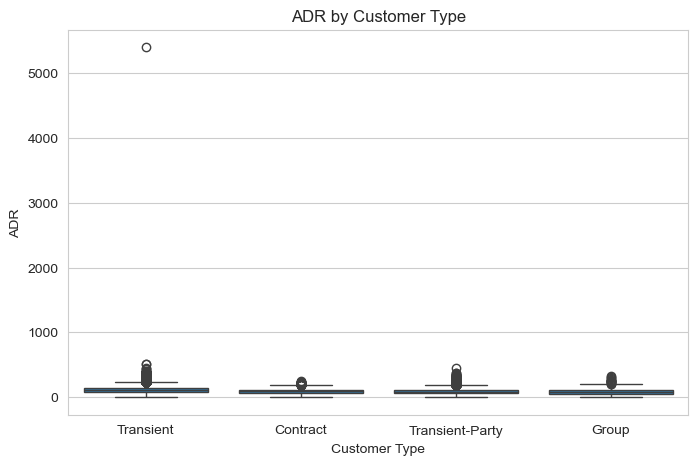

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='customer_type',
    y='adr',
    data=df
)

plt.title('ADR by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('ADR')

plt.show()

## Boxplot Analysis

### Why this Visualization?

A boxplot was used to compare ADR distributions across different customer types and identify differences in spending behavior, pricing patterns, variability, and unusual observations.

### Findings

* ADR distributions are relatively similar across all customer types.
* Transient customers show a slightly higher median ADR compared to other groups.
* Contract customers generally have lower ADR values.
* Multiple high ADR observations are present across customer categories.
* One extremely large ADR outlier (>5000) is observed within the Transient customer group.

### Interpretation

Transient customers appear to contribute slightly higher room revenue compared to other customer categories.

Contract customers tend to have lower room rates, likely due to negotiated pricing agreements.

The overall similarity of the distributions suggests that customer type alone does not create major differences in ADR.

### Special Observations

* The largest ADR value in the dataset belongs to a Transient customer booking.
* Several premium-priced bookings are visible among Transient and Transient-Party customers.
* The extreme ADR observation should not be considered representative of typical customer behavior.

### Business Insight

Transient customers form the largest customer group and also appear to generate slightly higher room revenue.

Hotels may benefit from focusing marketing and retention strategies on this segment while maintaining strong relationships with contract-based customers who provide stable booking demand.

### Conclusion

ADR varies only slightly across customer types. Transient customers show somewhat higher room rates, while Contract customers generally pay lower rates. Overall, customer type has a moderate influence on ADR but is not the primary driver of room pricing.


# Grouped Barplot Analysis

## Why this Analysis?

While boxplots compare the overall distribution of numerical variables across categories, grouped barplots compare summary statistics such as average values.

Grouped barplots provide a clearer business perspective by showing how different categories perform on average.

## Objective

To compare average values of important numerical variables across different categories and identify high-performing customer groups, booking channels, and hotel segments.

## Business Importance

This analysis helps:

* Identify profitable customer segments.
* Compare revenue performance across categories.
* Support pricing and marketing strategies.
* Generate actionable business insights.

## Why Grouped Barplots?

Grouped barplots are easier to interpret than boxplots when the goal is to compare average performance across categories.

They summarize large amounts of data into a simple visual comparison and help highlight meaningful differences between groups.


# Average ADR by Hotel Type

## Why These Variables?

ADR measures the average revenue earned per occupied room, while Hotel Type categorizes bookings into City Hotels and Resort Hotels.

Comparing average ADR across hotel types helps determine which category generates higher room revenue.

## Objective

To compare the average room rate earned by City Hotels and Resort Hotels.

## Business Importance

Understanding revenue differences between hotel types helps evaluate pricing strategies and identify stronger revenue-generating hotel categories.

## Expected Insight

A higher average ADR would indicate greater revenue generation potential and stronger pricing performance.


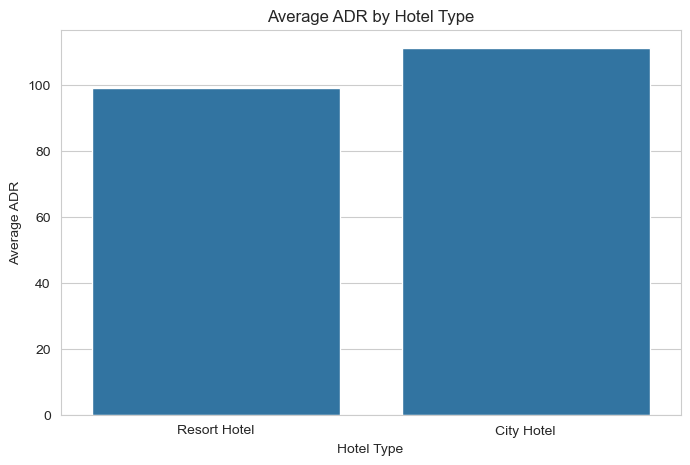

In [53]:
import numpy as np

plt.figure(figsize=(8,5))

sns.barplot(
    x='hotel',
    y='adr',
    data=df,
    estimator=np.mean,
    errorbar=None
)

plt.title('Average ADR by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average ADR')

plt.show()

## Grouped Barplot Analysis

### Why this Visualization?

A grouped barplot was used to compare the average ADR across hotel types.

Unlike boxplots, which focus on distributions and outliers, grouped barplots highlight average performance and make business comparisons easier to interpret.

### Use Case

This visualization helps:

* Compare average room revenue between hotel categories.
* Evaluate pricing effectiveness.
* Identify higher-performing hotel types.
* Support revenue management decisions.

### Findings

* City Hotels have a higher average ADR than Resort Hotels.
* The average ADR for City Hotels is approximately 111.
* The average ADR for Resort Hotels is approximately 99.
* The difference is clearly visible and easier to interpret than the boxplot.

### Interpretation

On average, City Hotels generate more room revenue per occupied room than Resort Hotels.

This suggests that City Hotels are able to charge slightly higher room rates, potentially due to location advantages, business travel demand, or customer preferences.

### Business Insight

City Hotels appear to have stronger pricing performance and revenue generation potential.

Understanding this difference can help hotel management evaluate pricing strategies and allocate resources more effectively.

### Conclusion

City Hotels achieve a higher average ADR than Resort Hotels, indicating stronger revenue performance. Hotel type therefore plays a meaningful role in determining room pricing and overall revenue generation.


# Average ADR by Market Segment

## Why These Variables?

ADR measures the average revenue earned per occupied room, while Market Segment identifies the source or category of customers making bookings.

Comparing average ADR across market segments helps determine which customer groups contribute the most revenue.

## Objective

To identify the market segments that generate the highest average room revenue.

## Business Importance

Understanding ADR differences among market segments helps hotels optimize marketing efforts, improve pricing strategies, and focus on high-value customer groups.

## Expected Insight

Some market segments may consistently generate higher ADR values, indicating stronger revenue potential and greater customer value.


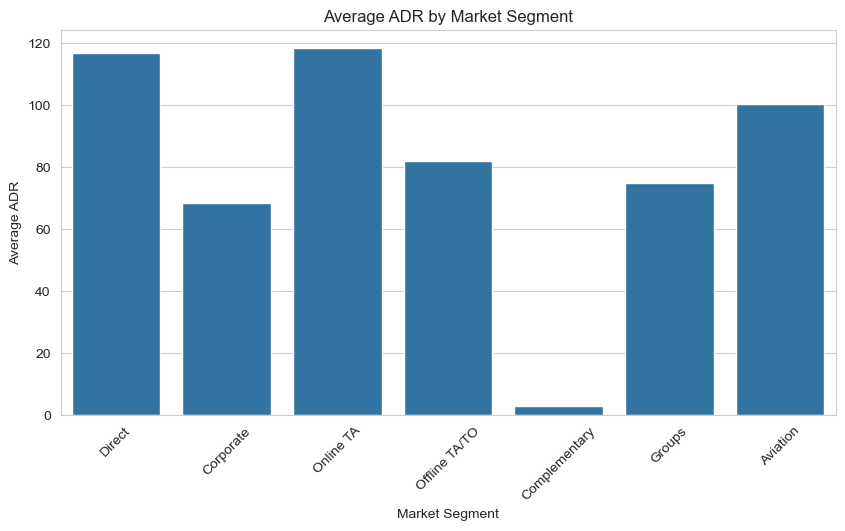

In [54]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='market_segment',
    y='adr',
    data=df,
    estimator=np.mean,
    errorbar=None
)

plt.xticks(rotation=45)

plt.title('Average ADR by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Average ADR')

plt.show()

## Grouped Barplot Analysis

### Why this Visualization?

A grouped barplot was used to compare the average ADR across market segments.

Unlike boxplots, which focus on distributions and variability, grouped barplots emphasize average performance, making it easier to identify the most valuable customer segments.

### Findings

* Online TA has the highest average ADR (approximately 118).
* Direct bookings have a very similar average ADR (approximately 117).
* Aviation bookings also generate relatively high ADR values (approximately 100).
* Offline TA/TO produces moderate ADR values (approximately 81).
* Corporate and Groups segments show lower ADR values.
* Complementary bookings generate almost no revenue, as expected.

### Interpretation

Customers arriving through Online Travel Agencies and Direct bookings tend to pay the highest room rates.

Corporate and Group bookings likely benefit from negotiated pricing and discounts, resulting in lower ADR values.

Complementary bookings are non-revenue-generating reservations, explaining the extremely low ADR.

### Special Observations

* Online TA slightly outperforms Direct bookings in average ADR.
* The difference between high-value and low-value segments is substantial.
* Market Segment has a clear impact on room pricing and revenue generation.

### Business Insight

Online TA and Direct channels represent the most profitable customer segments in terms of average room revenue.

Hotels should prioritize these channels through targeted marketing, promotional campaigns, and customer retention strategies.

Corporate and Group segments provide booking volume but generally contribute lower room revenue per booking.

### Conclusion

Market Segment significantly influences ADR. Online TA and Direct customers generate the highest average room revenue, while Corporate, Group, and Complementary segments contribute comparatively lower ADR values.


# Average Lead Time by Customer Type

## Why These Variables?

Lead Time measures how early customers make their bookings, while Customer Type categorizes guests based on booking behavior.

## Objective

To identify which customer groups tend to book further in advance.

## Business Importance

Understanding booking behavior helps improve forecasting, pricing strategies, and promotional planning.

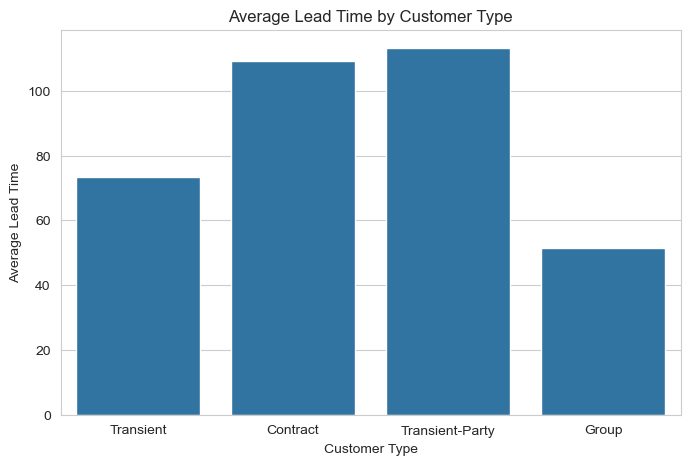

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='customer_type',
    y='lead_time',
    data=df,
    estimator=np.mean,
    errorbar=None
)

plt.title('Average Lead Time by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average Lead Time')

plt.show()

## Grouped Barplot Analysis

### Why this Visualization?

A grouped barplot was used to compare the average Lead Time across customer types.

This visualization summarizes booking behavior and makes it easy to identify which customer groups tend to book further in advance.

### Findings

* Transient-Party customers have the highest average Lead Time (approximately 113 days).
* Contract customers also book well in advance, with an average Lead Time of approximately 109 days.
* Transient customers have a lower average Lead Time of approximately 73 days.
* Group customers have the shortest average Lead Time, around 51 days.

### Interpretation

Transient-Party and Contract customers tend to plan their stays much earlier than other customer groups.

Transient customers generally make bookings closer to their arrival date, while Group bookings appear to be made with the shortest planning horizon.

This indicates clear differences in booking behavior among customer categories.

### Special Observations

* The difference between the highest and lowest average Lead Time is substantial.
* Customer Type has a stronger influence on Lead Time than it had on ADR.
* Booking behavior varies considerably across customer segments.

### Business Insight

Hotels can use these insights to design segment-specific strategies.

For example:

* Early-booking promotions can target Contract and Transient-Party customers.
* Last-minute offers may be more effective for Transient and Group customers.
* Demand forecasting can be improved by understanding how each customer segment books.

### Conclusion

Customer Type significantly influences Lead Time. Transient-Party and Contract customers book much earlier than other customer groups, while Group customers tend to book closer to their arrival date. These differences can support more effective pricing, marketing, and occupancy planning strategies.


# Segment Analysis

## What is Segment Analysis?

Segment Analysis is the process of dividing data into meaningful groups (segments) and comparing their behavior, performance, and characteristics.

Rather than analyzing all bookings together, segment analysis focuses on understanding how different categories of customers or bookings behave and contribute to business outcomes.

## Why Perform Segment Analysis?

Previous analyses helped us understand individual variables and relationships between variables. However, business decisions are often made by comparing specific groups of customers or bookings.

Segment Analysis helps uncover these differences and provides actionable business insights.

## Objective

To identify patterns, trends, and differences among various customer and booking segments and understand how these segments influence hotel performance.

## Business Importance

Segment Analysis helps hotels:

- Identify high-performing and low-performing customer groups.
- Understand booking and cancellation behavior.
- Improve pricing and marketing strategies.
- Optimize occupancy and revenue management.
- Support data-driven business decisions.

## Segments Considered in This Analysis

Since this dataset does not contain demographic variables such as age, gender, or region, the analysis focuses on business-related segments such as:

- Hotel Type
- Market Segment
- Customer Type
- Distribution Channel
- Reservation Status



# Reservation Status vs Hotel Type Analysis

## Why These Variables?

Reservation Status indicates the final outcome of a booking (Check-Out, Canceled, or No-Show), while Hotel Type categorizes bookings into City Hotels and Resort Hotels.

Analyzing these variables together helps determine whether booking outcomes differ between hotel categories.

## Objective

To compare reservation outcomes across hotel types and identify differences in customer booking behavior.

## Business Importance

Understanding reservation outcomes helps hotels:

- Improve occupancy planning.
- Reduce revenue loss from cancellations.
- Improve forecasting accuracy.
- Develop targeted customer retention strategies.

## Expected Insight

Different hotel types may experience different levels of cancellations and completed stays, which can significantly impact hotel performance and revenue.

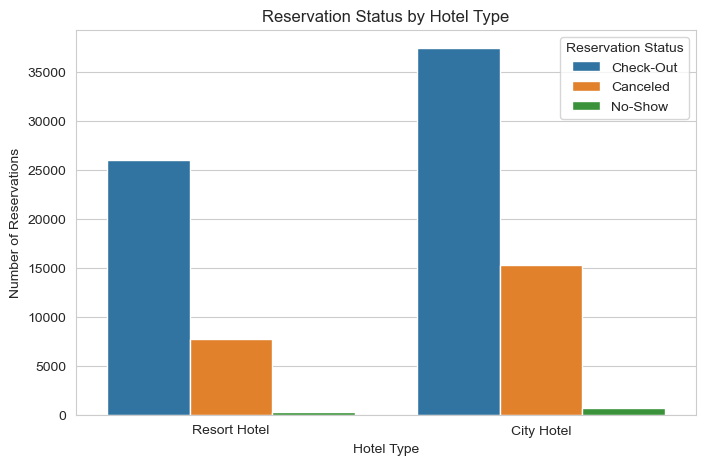

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='hotel',
    hue='reservation_status',
    data=df
)

plt.title('Reservation Status by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Reservations')

plt.legend(title='Reservation Status')

plt.show()

## Why this Visualization?

A grouped countplot was used to compare reservation outcomes across hotel types. This visualization helps identify how booking completion, cancellations, and no-show rates vary between City Hotels and Resort Hotels.

## Use Case

This visualization helps:

- Compare reservation outcomes between hotel categories.
- Identify cancellation patterns.
- Evaluate booking reliability.
- Support occupancy and revenue planning.

## Findings

- City Hotels have the highest number of completed stays (Check-Out).
- City Hotels also record the highest number of cancellations.
- Resort Hotels have fewer total reservations than City Hotels.
- No-Show reservations are very low in both hotel categories.
- Check-Out reservations are significantly higher than cancellations for both hotel types.

## Interpretation

City Hotels receive a larger volume of bookings, resulting in both more successful check-outs and more cancellations.

Although cancellations occur in both hotel types, most reservations ultimately lead to successful stays. This indicates that customer commitment remains strong across both hotel categories.

The low number of no-shows suggests that customers generally either complete their stay or formally cancel their reservation.

## Special Observations

- City Hotels experience nearly twice as many cancellations as Resort Hotels.
- Completed stays dominate reservation outcomes in both hotel categories.
- No-Show bookings contribute only a very small fraction of total reservations.

## Business Insight

Since City Hotels experience a higher number of cancellations, hotel management may benefit from implementing stronger cancellation management strategies, reminder systems, or targeted customer retention initiatives.

Despite higher cancellations, City Hotels remain the largest contributor to successful stays and overall revenue generation.

## Conclusion

Reservation outcomes differ between hotel types primarily because City Hotels handle a larger booking volume. Successful check-outs remain the dominant outcome for both hotel categories, while cancellations represent the second most common outcome. No-show reservations are minimal, indicating effective booking management and customer commitment.

# Reservation Status vs Market Segment Analysis

## Why These Variables?

Reservation Status indicates the final outcome of a booking (Check-Out, Canceled, or No-Show), while Market Segment identifies the source or category of customers making reservations.

Analyzing these variables together helps determine whether booking outcomes differ across customer segments.

## Objective

To compare reservation outcomes among market segments and identify segments with higher cancellation rates and successful stay rates.

## Business Importance

Understanding reservation behavior across market segments helps hotels:

- Identify reliable customer segments.
- Reduce cancellation-related revenue loss.
- Improve marketing strategies.
- Optimize customer acquisition efforts.
- Support revenue management decisions.

## Expected Insight

Different market segments may exhibit different booking behaviors. Some segments may generate more successful stays, while others may contribute more cancellations.

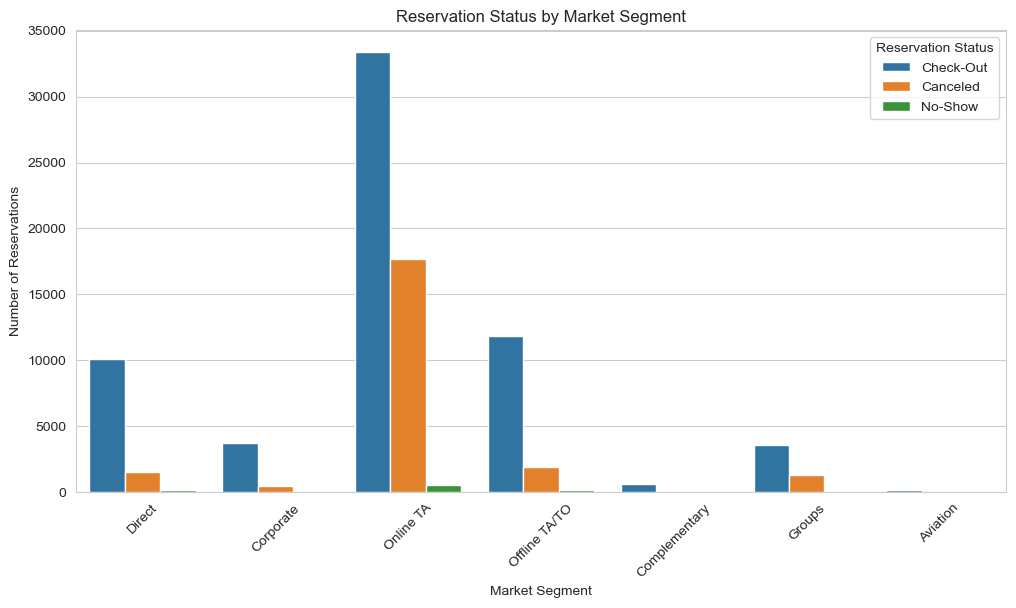

In [57]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='market_segment',
    hue='reservation_status',
    data=df
)

plt.xticks(rotation=45)

plt.title('Reservation Status by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Reservations')

plt.legend(title='Reservation Status')

plt.show()

## Why this Visualization?

A grouped countplot was used to compare reservation outcomes across different market segments.

This visualization helps identify which customer segments generate the most successful stays, cancellations, and no-show reservations.

## Use Case

This visualization helps:

- Compare booking outcomes among market segments.
- Identify segments with high cancellation rates.
- Evaluate customer reliability.
- Support marketing and revenue management strategies.

## Findings

- Online TA generates the highest number of reservations overall.
- Online TA also records the highest number of cancellations.
- Direct and Offline TA/TO segments contribute a large number of successful check-outs.
- Corporate and Groups segments show relatively lower booking volumes.
- No-show reservations remain very low across all market segments.
- Complementary and Aviation segments contribute only a small number of reservations.

## Interpretation

Online TA is the dominant booking segment, producing the largest number of completed stays as well as the highest number of cancellations.

Although Online TA experiences many cancellations, successful check-outs still significantly exceed canceled bookings.

Direct bookings appear more reliable, with a much larger proportion of completed stays compared to cancellations.

The low number of no-shows across all segments indicates that most customers either complete their stay or cancel in advance.

## Special Observations

- Online TA is both the most valuable and the riskiest segment due to its large booking volume and cancellation count.
- Direct bookings show strong booking completion performance.
- Complementary and Aviation segments have minimal impact on overall reservation outcomes.
- No-show reservations are negligible across all customer segments.

## Business Insight

Hotels should continue leveraging Online TA channels because they generate the highest booking volume and revenue opportunities.

However, additional cancellation management strategies may be required for Online TA customers.

Direct bookings appear highly valuable due to their strong conversion into successful stays and relatively lower cancellation levels.

## Conclusion

Reservation outcomes vary across market segments. Online TA dominates booking activity and successful stays but also contributes the highest number of cancellations. Direct bookings demonstrate stronger reservation reliability, making them an important segment for long-term business growth.

# Reservation Status vs Distribution Channel Analysis

## Why These Variables?

Reservation Status indicates the final outcome of a booking, while Distribution Channel represents the platform through which the reservation was made.

Analyzing these variables together helps determine whether booking outcomes differ across reservation channels.

## Objective

To compare reservation outcomes across distribution channels and identify the most reliable booking sources.

## Business Importance

Understanding channel performance helps hotels:

- Improve channel management.
- Reduce cancellation-related losses.
- Focus on high-performing booking sources.
- Optimize customer acquisition strategies.

## Expected Insight

Some distribution channels may produce more successful stays, while others may contribute disproportionately to cancellations.

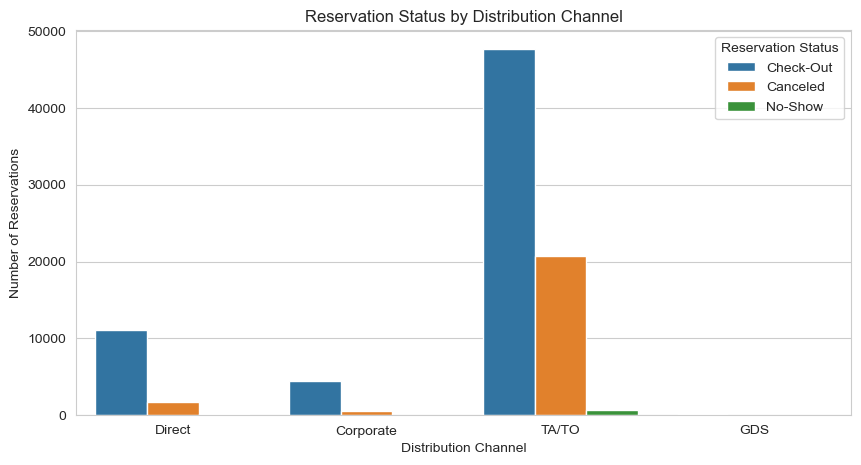

In [58]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='distribution_channel',
    hue='reservation_status',
    data=df
)

plt.title('Reservation Status by Distribution Channel')
plt.xlabel('Distribution Channel')
plt.ylabel('Number of Reservations')

plt.legend(title='Reservation Status')

plt.show()

## Why this Visualization?

A grouped countplot was used to compare reservation outcomes across distribution channels.

This visualization helps identify which booking channels generate the highest number of successful stays, cancellations, and no-show reservations.

## Use Case

This visualization helps:

- Evaluate the performance of booking channels.
- Compare cancellation behavior across channels.
- Identify reliable reservation sources.
- Support channel management and revenue optimization strategies.

## Findings

- TA/TO (Travel Agents/Tour Operators) is the dominant distribution channel, generating the highest number of reservations.
- TA/TO also records the highest number of cancellations.
- Direct bookings show a high number of successful check-outs with relatively fewer cancellations.
- Corporate bookings contribute a moderate number of completed stays and very few cancellations.
- GDS contributes only a negligible number of reservations.
- No-show reservations remain very low across all distribution channels.

## Interpretation

TA/TO serves as the primary source of bookings and successful stays. However, because it handles the largest booking volume, it also experiences the highest number of cancellations.

Direct bookings demonstrate strong reservation reliability, with a significantly larger proportion of successful stays compared to cancellations.

Corporate bookings appear stable and reliable, while GDS has minimal influence on overall reservation outcomes.

## Special Observations

- TA/TO dominates both successful stays and cancellations.
- Direct bookings exhibit strong conversion from reservation to completed stay.
- No-show reservations are extremely rare across all channels.
- GDS contributes very little to total booking activity.

## Business Insight

Hotels should continue leveraging TA/TO channels because they generate the largest booking volume and revenue opportunities.

However, cancellation management strategies should focus particularly on TA/TO bookings to reduce potential revenue loss.

Direct bookings appear highly valuable due to their strong completion rates and lower cancellation levels.

## Conclusion

Distribution Channel significantly influences reservation outcomes. TA/TO is the primary source of bookings and successful stays but also contributes the highest number of cancellations. Direct and Corporate channels demonstrate stronger booking reliability and may provide opportunities for more stable revenue generation.

# Overall Day 3 Insights

## Key Findings

### Univariate Analysis
- Most bookings were made for 2 adults.
- The majority of customers made no special requests.
- City Hotels received more bookings than Resort Hotels.
- Online TA was the dominant market segment.
- Most customers were classified as Transient.
- Most reservations required no deposit.

### Numeric–Numeric Analysis
- Lead Time and ADR showed almost no correlation (r ≈ 0.02).
- Total Special Requests showed a weak positive relationship with ADR (r ≈ 0.14).
- No strong linear relationships were observed among most numerical variables.

### Numeric–Categorical Analysis
- City Hotels achieved a higher average ADR than Resort Hotels.
- Online TA and Direct segments generated the highest ADR values.
- Customer Type influenced Lead Time more strongly than ADR.

### Segment Analysis
- City Hotels recorded more check-outs and more cancellations.
- Online TA generated the highest booking volume and the highest number of cancellations.
- Direct bookings showed strong reservation reliability.
- TA/TO was the dominant distribution channel for hotel reservations.

## Conclusion

The analysis revealed that customer segments, booking channels, and hotel types significantly influence booking behavior and revenue performance. While City Hotels, Online TA, and TA/TO channels contribute the highest booking volumes and revenue opportunities, they also account for a larger share of cancellations. These insights can help hotels improve pricing strategies, optimize channel management, reduce cancellations, and enhance overall business performance.

# Limitations

- Some variables contained extreme outliers that affected visualizations.
- Correlation analysis only captures linear relationships.
- Findings are based on the available booking records and may not represent future booking behavior.